In [1]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
# find -L /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/align_dna/GRCh37 -name "*.bam" -exec realpath {} + > /mnt/NAS3/home/jiwon/ECTRES/data/bam_list_all_origin.txt

In [8]:
# 파일 경로 설정
file_path = '/mnt/NAS3/home/jiwon/ECTRES/data/bam_list_all_origin.txt'

# 파일 읽기
with open(file_path, 'r') as f:
    bam_paths = f.read().splitlines()

data = []
for path in bam_paths:
    # 경로를 'GRCh37/' 기준으로 나누어 그 바로 뒤의 폴더명을 가져옵니다.
    # 예: .../GRCh37/ECTRES-XXXX/applyBqsr/... -> ECTRES-XXXX
    try:
        barcode = path.split('GRCh37/')[1].split('/')[0]
        data.append({'aliquot_barcode': barcode, 'bam': path})
    except IndexError:
        # 경로 형식이 다를 경우를 대비한 예외 처리
        print(f"경로 형식이 맞지 않음: {path}")

# 3. 데이터프레임 생성
df = pd.DataFrame(data)

# 4. 결과 확인
print(f"총 {len(df)}개의 샘플이 로드되었습니다.")
display(df.head())

총 77개의 샘플이 로드되었습니다.


,aliquot_barcode,bam
0,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
2,ECTRES-ECGI1-0001-TPX-A02-WGS-5KM079,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
3,ECTRES-ECGI1-0001-TPX-A03-WGS-0LT586,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
4,ECTRES-ECGI1-0001-TPX-A04-WGS-0SR571,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...


In [3]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
bam_manifest = manifest[['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_type', 'tumor_or_normal', 'sequence_type',
       'sample_legacy_id', 'gender','action', 'sample_id']].drop_duplicates()

# print(manifest.shape, sample_mapping.shape) #(87, 19) (77, 5)
print(manifest.shape, bam_manifest.shape) #(87, 19) (77, 11)

(87, 19) (77, 11)


In [4]:
bam_manifest.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [17]:
bam_manifest= pd.merge(bam_manifest, df, on='aliquot_barcode', how='left')

In [19]:
bam_manifest['bai']=bam_manifest['bam']+'.bai'

In [28]:
bam_manifest.head(2)

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,action,sample_id,bam,bai
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,NaN,EG_1,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
1,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_10,XY,NaN,EG_10,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...


In [39]:
bam_manifest[bam_manifest['sample_id']=='parental']

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,action,sample_id,bam,bai
50,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,H2170,ECTRES-H2170-0001-TPX-A01,ECTRES-H2170-0001,TP,tumor,WGS,NaN,XY,NaN,parental,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
51,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,NaN,XY,NaN,parental,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...,/mnt/NAS3/home/mary/HL-NF/scratch/ECTRES/resul...
52,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,ECTRES-EFM19-0001-TPX-A01,ECTRES-EFM19-0001,TP,tumor,WGS,NaN,XX,NaN,parental,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...


In [5]:
# bam_manifest.to_csv('../manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309
# bam_manifest.to_csv('/mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv',index=False)  ## 20260309
bam_manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_bam.csv')  ## 20260309


In [42]:
root_path = '/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/ichorCNA/v2/'

# 2. 모든 하위 폴더에서 .params.txt 파일 찾기
# 예: .../ichorCNA/Sample_Folder/Sub_Folder/Sample_Name.params.txt
param_files = glob.glob(os.path.join(root_path, "**/*.params.txt"), recursive=True)

all_results = []

for file in param_files:
    # 'n_0'로 시작하는 하단 Likelihood 테이블은 무시하고 상단 정보만 가져오기 위해
    # 딕셔너리 형태로 데이터를 파싱합니다.
    sample_info = {}
    
    with open(file, 'r') as f:
        lines = f.readlines()
        
        # Gender 필드가 있는 지점부터가 우리가 원하는 블록입니다.
        # 그 바로 윗줄이 샘플 이름입니다.
        for i, line in enumerate(lines):
            if "Gender:" in line:
                # 샘플 이름 저장 (Gender 윗줄)
                sample_info['Sample'] = lines[i-1].strip()
                
                # Gender 줄부터 아래로 내려가며 Key: Value 파싱
                for j in range(i, len(lines)):
                    current_line = lines[j].strip()
                    
                    # 빈 줄이거나 하단 테이블(n_0)이 시작되면 멈춤
                    if not current_line or current_line.startswith('n_0'):
                        break
                    
                    if ":" in current_line:
                        key, val = current_line.split(":", 1)
                        sample_info[key.strip()] = val.strip()
                break # 원하는 블록을 다 읽었으면 해당 파일 종료
                
    if sample_info:
        all_results.append(sample_info)

# 3. 데이터프레임 생성
df_ichor = pd.DataFrame(all_results)

# 4. 컬럼 순서 정리 (Sample을 가장 앞으로)
cols = ['Sample'] + [c for c in df_ichor.columns if c != 'Sample']
df_ichor = df_ichor[cols]

# 5. 결과 확인
print(f"총 {len(df_ichor)}개의 샘플 파라미터를 읽어왔습니다.")

df_ichor['aliquot_barcode']=df_ichor['Sample']
display(df_ichor.head())

# (팁) 엑셀이나 CSV로 저장하고 싶으시면 아래 주석 해제
# df_ichor.to_csv('ichorCNA_summary_table.csv', index=False)

총 77개의 샘플 파라미터를 읽어왔습니다.


,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,5.262,NA,0,0,NA,0.0003642,-0.8113,"-1.7, -0.97, -0.56, -0.27, -0.051, 0.13, 0.29","51, 23, 260, 240, 170, 270, 54",0.039,0.06895,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349
1,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,female,1,2.784,NA,0,0,NA,3.755e-05,-0.515,"-1, -0.33, 0.075, 0.36, 0.59, 0.77, 0.92","67, 290, 310, 430, 100, 67, 46",0.03,0.05942,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757
2,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,female,1,3.398,NA,0,0,NA,4.338e-05,-0.8211,"-1.2, -0.53, -0.12, 0.16, 0.39, 0.57, 0.72","180, 240, 270, 240, 200, 260, 47",0.057,0.07693,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851
3,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826,female,1,3.38,NA,0,0,NA,4.406e-05,-0.8102,"-1.2, -0.52, -0.12, 0.17, 0.39, 0.57, 0.73","200, 170, 240, 260, 250, 89, 20",0.058,0.076,ECTRES-ECGI1-0001-TPX-A29-WGS-1IJ826
4,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676,female,1,3.427,NA,0,0,NA,0.0006422,-0.8607,"-1.2, -0.54, -0.13, 0.15, 0.38, 0.56, 0.71","220, 270, 270, 320, 290, 66, 24",0.046,0.07215,ECTRES-ECGI1-0001-TPX-A28-WGS-1QA676


In [43]:
ichor_df= pd.merge(df_ichor, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')

ichor_df.shape

(77, 17)

In [124]:
# ichor_df.to_csv('../summary/ichorCNA_summary_origin.csv', index=False)
# ichor_df.to_csv('../summary/ichorCNA_summary_tumor_only.csv', index=False)
ichor_df=pd.read_csv('../summary/ichorCNA_summary_tumor_only.csv')
ichor_df.shape #(77, 17)
ichor_df.head(2)

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,5.262,NaN,0,0,NaN,0.000364,-0.8113,"-1.7, -0.97, -0.56, -0.27, -0.051, 0.13, 0.29","51, 23, 260, 240, 170, 270, 54",0.039,0.06895,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,EG_1
1,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,female,1,2.784,NaN,0,0,NaN,0.000038,-0.5150,"-1, -0.33, 0.075, 0.36, 0.59, 0.77, 0.92","67, 290, 310, 430, 100, 67, 46",0.030,0.05942,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,ECGI1,EG_21


In [126]:
aaSuite_gemline_ms = ichor_df.copy()
aaSuite_gemline_ms['old_source_barcode'] = aaSuite_gemline_ms['source_barcode']
aaSuite_gemline_ms['old_sample_id'] = aaSuite_gemline_ms['sample_id']

# 2. 첫 번째 케이스: ECGI1 + EG_21 조합인 경우만 H2170 + NCI_40으로 변경
cond1 = (aaSuite_gemline_ms['old_source_barcode'] == 'ECGI1') & (aaSuite_gemline_ms['old_sample_id'] == 'EG_21')
aaSuite_gemline_ms.loc[cond1, 'source_barcode'] = 'H2170'
aaSuite_gemline_ms.loc[cond1, 'sample_id'] = 'NCI_40'

# 3. 두 번째 케이스: H2170 + NCI_10 조합인 경우만 ECGI1 + EG_40으로 변경
cond2 = (aaSuite_gemline_ms['old_source_barcode'] == 'H2170') & (aaSuite_gemline_ms['old_sample_id'] == 'NCI_10')
aaSuite_gemline_ms.loc[cond2, 'source_barcode'] = 'ECGI1'
aaSuite_gemline_ms.loc[cond2, 'sample_id'] = 'EG_40'

ichor_df = aaSuite_gemline_ms.copy()
# ichor_df.to_csv('../summary/ichorCNA_summary_params_20260331.csv', index=False)



In [127]:
ichor_df.head(2)

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id,old_source_barcode,old_sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,female,1,5.262,NaN,0,0,NaN,0.000364,-0.8113,"-1.7, -0.97, -0.56, -0.27, -0.051, 0.13, 0.29","51, 23, 260, 240, 170, 270, 54",0.039,0.06895,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,EG_1,ECGI1,EG_1
1,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,female,1,2.784,NaN,0,0,NaN,0.000038,-0.5150,"-1, -0.33, 0.075, 0.36, 0.59, 0.77, 0.92","67, 290, 310, 430, 100, 67, 46",0.030,0.05942,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,H2170,NCI_40,H2170,NCI_40


In [48]:
ichor_df.columns

Index(['Sample', 'Gender', 'Tumor Fraction', 'Ploidy', 'Subclone Fraction',
       'Fraction Genome Subclonal', 'Fraction CNA Subclonal', 'Coverage',
       'ChrY coverage fraction', 'ChrX median log ratio', 'Student's t mean',
       'Student's t precision', 'Gamma Rate Init', 'GC-Map correction MAD',
       'aliquot_barcode', 'source_barcode', 'sample_id'],
      dtype='object')

In [52]:
ichor_df['GC-Map correction MAD'].max()
# ichor_df['Fraction CNA Subclonal'].max()
# ichor_df['Coverage'].max()

'0.08286'

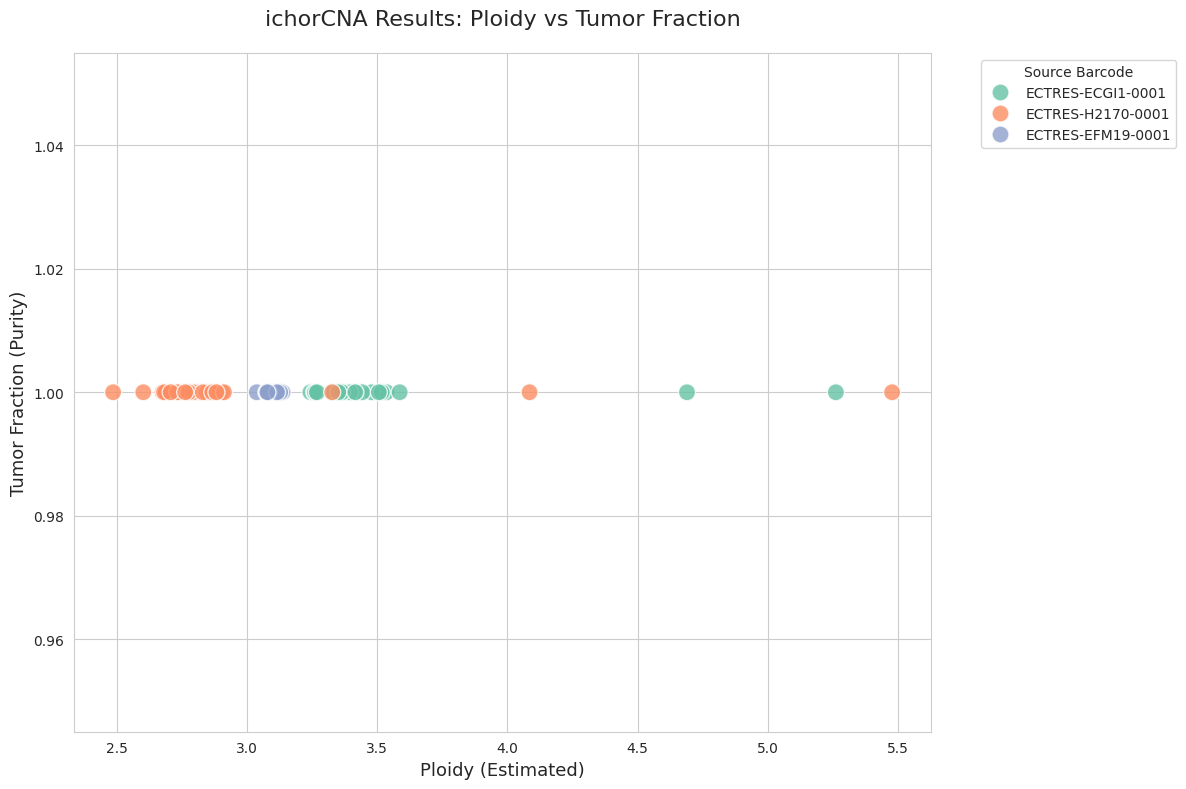

In [47]:
df_ichor=ichor_df.copy()
# 1. 데이터 타입 변환 (숫자형으로 확정)
df_ichor['Ploidy'] = pd.to_numeric(df_ichor['Ploidy'], errors='coerce')
df_ichor['Tumor Fraction'] = pd.to_numeric(df_ichor['Tumor Fraction'], errors='coerce')

# 2. source_barcode 추출 (예: ECTRES-ECGI1-0001-TPX... -> ECTRES-ECGI1-0001)
# 샘플 이름의 구조에 따라 하이픈(-) 기준 앞 3 덩어리를 합칩니다.
df_ichor['source_barcode'] = df_ichor['Sample'].apply(lambda x: "-".join(x.split("-")[:3]))

# 3. 그래프 그리기
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 산점도 생성
scatter = sns.scatterplot(
    data=df_ichor, 
    x='Ploidy', 
    y='Tumor Fraction', 
    hue='source_barcode', 
    palette='Set2',      # 색상 테마 (샘플이 아주 많으면 'husl'이나 'tab20' 추천)
    s=150,               # 점 크기
    alpha=0.8,           # 투명도
    edgecolor='w'        # 점 테두리 흰색
)

# 4. 그래프 꾸미기
plt.title('ichorCNA Results: Ploidy vs Tumor Fraction', fontsize=16, pad=20)
plt.xlabel('Ploidy (Estimated)', fontsize=13)
plt.ylabel('Tumor Fraction (Purity)', fontsize=13)

# 범례(Legend) 위치 조정 (그래프 밖으로 빼서 가독성 확보)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Source Barcode', fontsize=10)

# 5. 축 범위 자동 조정 및 레이아웃 정리
plt.tight_layout()

# 그래프 저장 (선택 사항)
# plt.savefig('ichorCNA_scatter_plot.png', dpi=300)

plt.show()

In [54]:
df_ichor = ichor_df.copy()

candidate_cols = [
    'Ploidy',
    'Coverage',
    'ChrY coverage fraction',
    'ChrX median log ratio',
    "Student's t mean",
    "Student's t precision",
    'Gamma Rate Init',
    'GC-Map correction MAD'
]

for col in candidate_cols:
    df_ichor[col] = pd.to_numeric(df_ichor[col], errors='coerce')

summary_check = pd.DataFrame({
    'n_non_na': df_ichor[candidate_cols].notna().sum(),
    'n_unique': df_ichor[candidate_cols].nunique(dropna=True),
    'min': df_ichor[candidate_cols].min(),
    'max': df_ichor[candidate_cols].max()
}).sort_values('n_unique', ascending=False)

summary_check

,n_non_na,n_unique,min,max
ChrX median log ratio,77,76,-1.765000,0.332600
GC-Map correction MAD,77,76,0.044970,0.082860
ChrY coverage fraction,77,75,0.000038,0.000747
Ploidy,77,73,2.485000,5.478000
Gamma Rate Init,77,29,0.026000,0.066000
Coverage,0,0,NaN,NaN
Student's t mean,0,0,NaN,NaN
Student's t precision,0,0,NaN,NaN


In [ ]:
# nextflow run main.nf -profile singularity   --input /mnt/NAS3/home/jiwon/ECTRES/manifest/ECTRES_clones_nf_dna_bam.csv   --outdir /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/ichorCNA/v2/   --window 500000   -w /mnt/NAS3/home/jiwon/HL-NF//nxf_work/ichor -resume

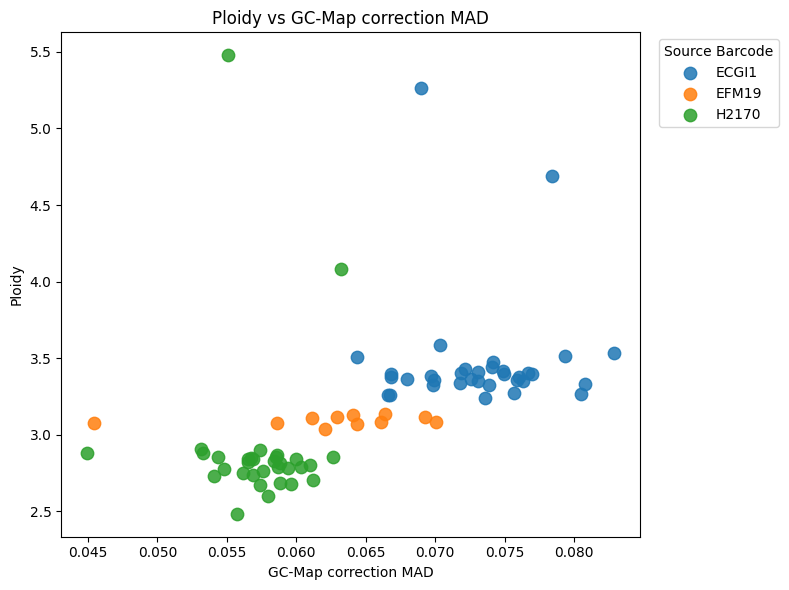

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. parental 제외
# df_plot = df_plot[~df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

# 3. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode'])

# 4. 그룹별 색 지정
group_order = sorted(df_plot['source_barcode'].dropna().unique())
colors = plt.cm.Set2(range(len(group_order)))
color_map = dict(zip(group_order, colors))

# 5. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

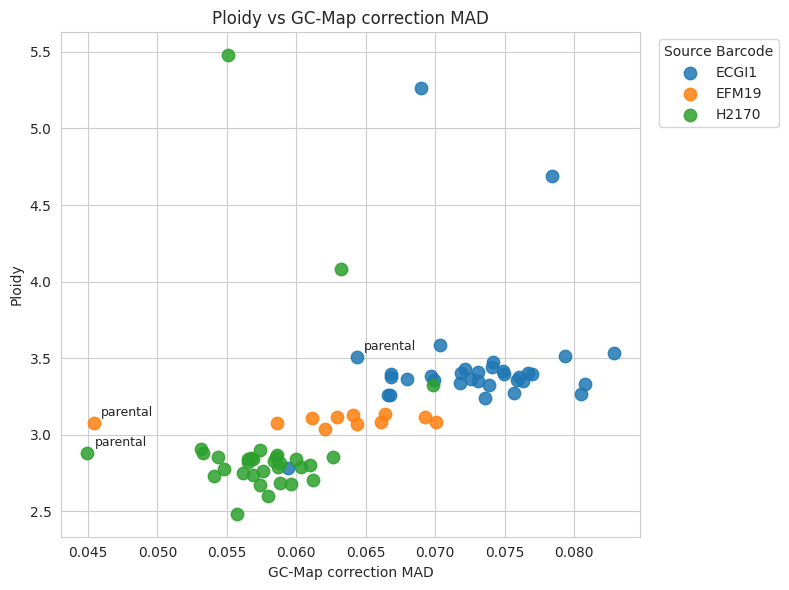

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = ichor_df.copy()

# 1. 문자열 공백 제거 후 숫자형 변환
for col in ['Ploidy', 'GC-Map correction MAD']:
    df_plot[col] = (
        df_plot[col]
        .astype(str)
        .str.strip()
        .replace({'nan': pd.NA, 'NA': pd.NA, '': pd.NA})
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# 2. NA 제거
df_plot = df_plot.dropna(subset=['Ploidy', 'GC-Map correction MAD', 'source_barcode', 'sample_id'])

# 3. 그룹 순서
group_order = sorted(df_plot['source_barcode'].dropna().unique())

# 4. scatter plot
plt.figure(figsize=(8, 6))

for group in group_order:
    sub = df_plot[df_plot['source_barcode'] == group]
    plt.scatter(
        sub['GC-Map correction MAD'],
        sub['Ploidy'],
        label=group,
        s=80,
        alpha=0.85
    )

# 5. parental 샘플만 annotation
parental_df = df_plot[df_plot['sample_id'].str.contains('parental', case=False, na=False)].copy()

for _, row in parental_df.iterrows():
    plt.annotate(
        row['sample_id'],
        (row['GC-Map correction MAD'], row['Ploidy']),
        xytext=(5, 5),          # 점에서 살짝 오른쪽 위
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('GC-Map correction MAD')
plt.ylabel('Ploidy')
plt.title('Ploidy vs GC-Map correction MAD')
plt.legend(title='Source Barcode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
q1 = df_plot['GC-Map correction MAD'].quantile(0.25)
q3 = df_plot['GC-Map correction MAD'].quantile(0.75)
iqr = q3 - q1
cutoff = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Suggested outlier cutoff:", cutoff)

df_plot['MAD_outlier'] = df_plot['GC-Map correction MAD'] > cutoff
df_plot[['sample_id', 'source_barcode', 'GC-Map correction MAD', 'Ploidy', 'MAD_outlier']].sort_values(
    'GC-Map correction MAD', ascending=False
).head(15)

Q1: 0.05856
Q3: 0.07294
IQR: 0.014380000000000004
Suggested outlier cutoff: 0.09451000000000001


,sample_id,source_barcode,GC-Map correction MAD,Ploidy,MAD_outlier
13,EG_18,ECGI1,0.08286,3.536,False
18,EG_26,ECGI1,0.08074,3.332,False
26,EG_3,ECGI1,0.08051,3.268,False
29,EG_6,ECGI1,0.07935,3.517,False
23,EG_5,ECGI1,0.07840,4.690,False
2,EG_27,ECGI1,0.07693,3.398,False
10,EG_8,ECGI1,0.07665,3.401,False
31,EG_11,ECGI1,0.07633,3.350,False
3,EG_29,ECGI1,0.07600,3.380,False
28,EG_4,ECGI1,0.07590,3.360,False


In [77]:
df_plot.head(2)
df_plot[(df_plot['source_barcode']=='H2170')&(df_plot['Ploidy']>3)]

ichor_df[(ichor_df['sample_id']=='parental')&(ichor_df['source_barcode']=='EFM19')]

,Sample,Gender,Tumor Fraction,Ploidy,Subclone Fraction,Fraction Genome Subclonal,Fraction CNA Subclonal,Coverage,ChrY coverage fraction,ChrX median log ratio,Student's t mean,Student's t precision,Gamma Rate Init,GC-Map correction MAD,aliquot_barcode,source_barcode,sample_id
76,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,female,1,3.078,NA,0,0,NA,5.387e-05,0.3302,"-1.1, -0.43, -0.026, 0.26, 0.49, 0.67, 0.82","280, 660, 840, 530, 280, 13, 2.3",0.049,0.04543,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,parental


## ECTRES_ichorCNA_correctedDepth_20260319.csv

In [86]:
correctedDepth = pd.read_csv('../summary/ichorCNA/ECTRES_ichorCNA_correctedDepth_20260319.csv')


correctedDepth= pd.merge(correctedDepth, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')


print(correctedDepth.shape)

correctedDepth.head(2)

(402633, 7)


,aliquot_barcode,chr,start,end,log2_TNratio_corrected,source_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1000001,1500000,NaN,ECGI1,EG_1
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,1,1500001,2000000,1.260567,ECGI1,EG_1


In [87]:
correctedDepth[correctedDepth['sample_id']=='parental']

,aliquot_barcode,chr,start,end,log2_TNratio_corrected,source_barcode,sample_id
172557,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1,1000001,1500000,NaN,ECGI1,parental
172558,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1,1500001,2000000,1.697611,ECGI1,parental
172559,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1,2000001,2500000,NaN,ECGI1,parental
172560,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1,3000001,3500000,0.229425,ECGI1,parental
172561,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,1,4000001,4500000,0.588324,ECGI1,parental
...,...,...,...,...,...,...,...
402628,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,150000001,150500000,0.339154,EFM19,parental
402629,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,150500001,151000000,0.238562,EFM19,parental
402630,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,151000001,151500000,0.291746,EFM19,parental
402631,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,X,152500001,153000000,0.380819,EFM19,parental


<Figure size 1000x800 with 0 Axes>

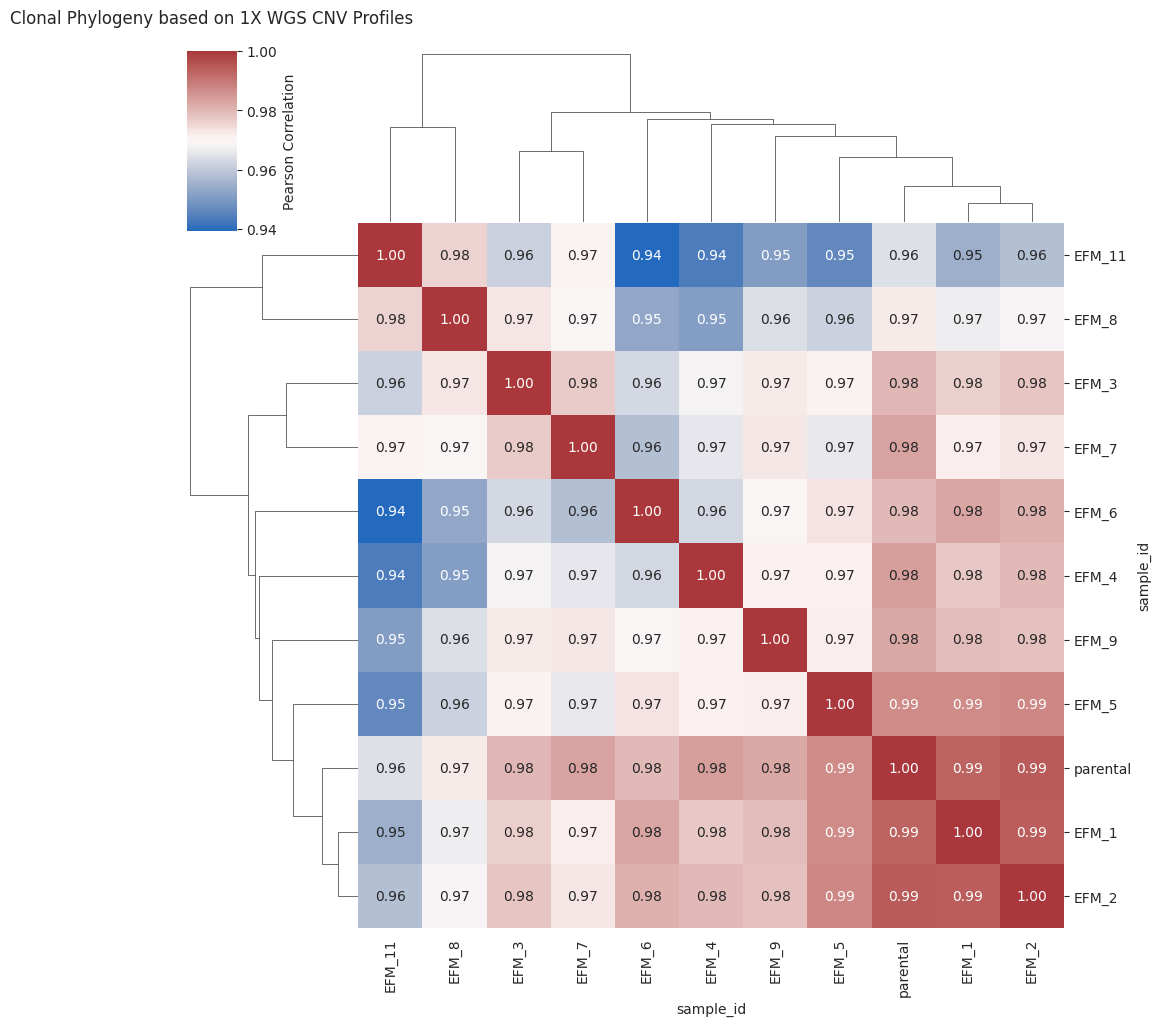

In [90]:
# df = correctedDepth[(correctedDepth['source_barcode']=='EFM19')&(correctedDepth['sample_id']!='parental')]
df = correctedDepth[(correctedDepth['source_barcode']=='EFM19')]

df_wide = df.pivot_table(
    index=['chr', 'start', 'end'], 
    columns='sample_id', 
    values='log2_TNratio_corrected'
).dropna()

# 3. 샘플 간 상관계수(Correlation) 행렬 계산
corr_matrix = df_wide.corr()

# 4. Clustermap 시각화 (계통수 확인)
plt.figure(figsize=(10, 8))
sns.clustermap(corr_matrix, cmap='vlag', annot=True, fmt=".2f",
               cbar_kws={'label': 'Pearson Correlation'})
plt.title('Clonal Phylogeny based on 1X WGS CNV Profiles', pad=20)
plt.show()

In [96]:
# df_wide.shape

[*] Linearizing genomic coordinates...
[*] Generating Genome-wide CNV Plot...


<ipython-input-93-45bc43b0581e>:97: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in leg.legendHandles:


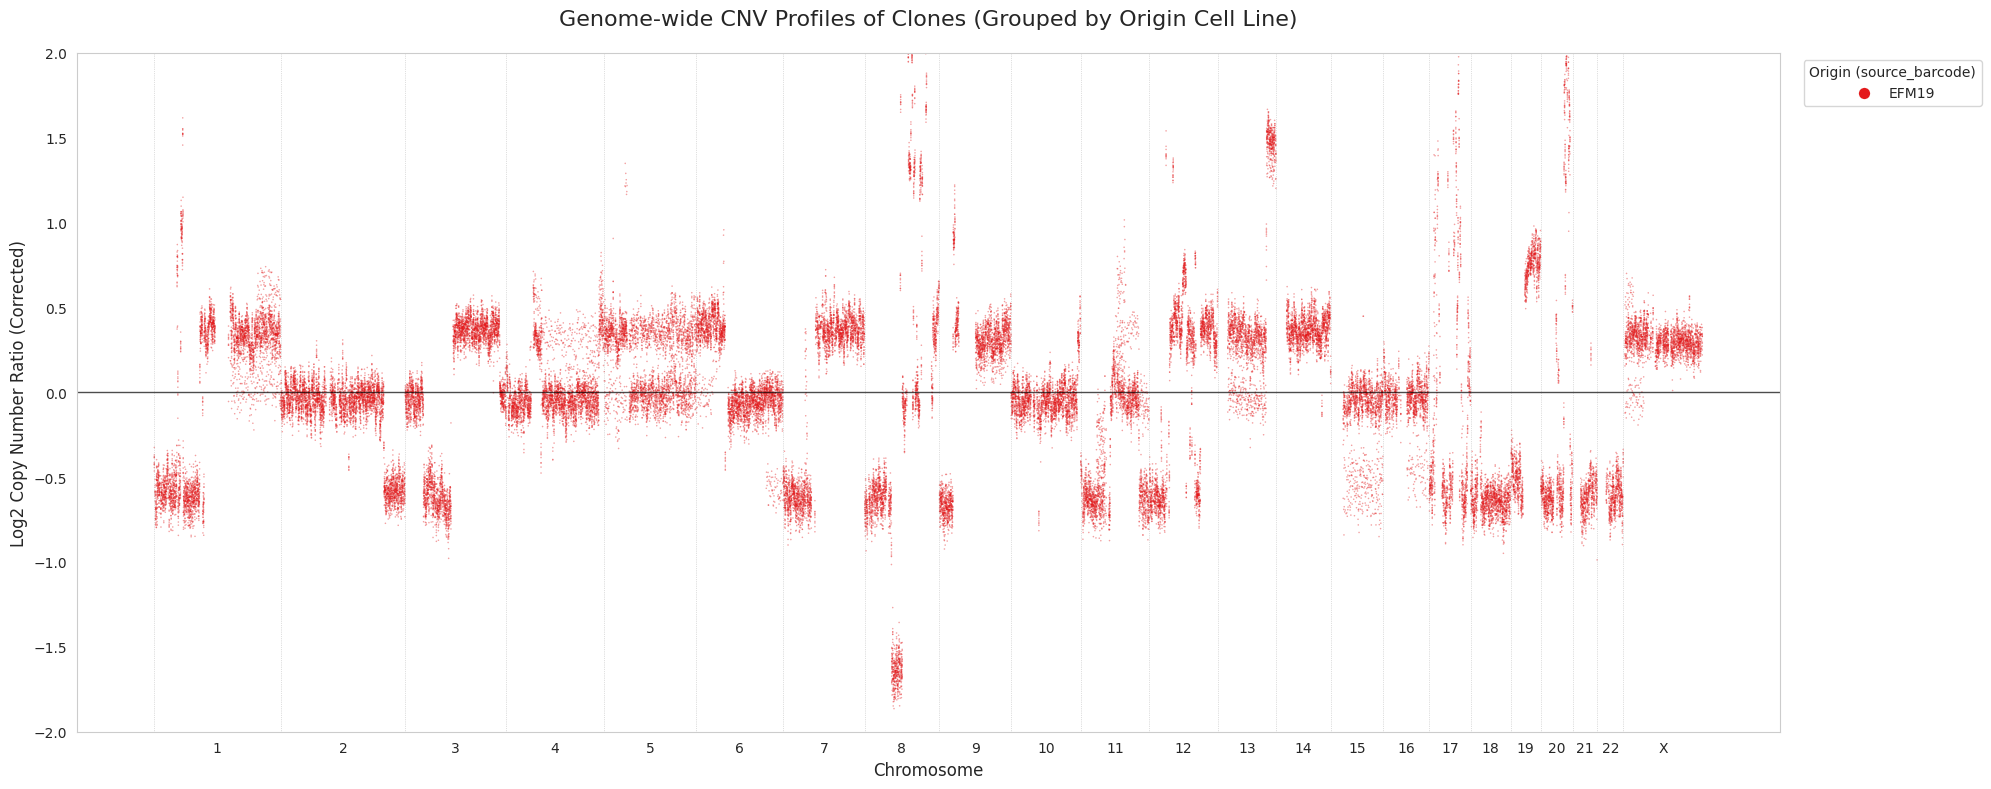

[*] Process completed.


In [93]:
# 3. 데이터 필터링: sample_id가 'parental'인 것 제외
df_plot = df[df['sample_id'] != 'parental'].copy()
df_plot = df.copy()

# 4. NA 값 제거 (시각화 오류 방지)
df_plot = df_plot.dropna(subset=['log2_TNratio_corrected'])


print("[*] Linearizing genomic coordinates...")

# 염색체 순서 정의 (숫자 -> 문자 순 정렬 방지)
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
# 데이터 내 염색체 컬럼을 Categorical 타입으로 변환하여 순서 고정
df_plot['chr'] = pd.Categorical(df_plot['chr'].astype(str), categories=chrom_order, ordered=True)
df_plot = df_plot.sort_values(['chr', 'start'])

# 각 염색체의 누적 길이를 계산하여 오프셋(Offset) 생성
cumulative_pos = 0
chrom_offsets = {}
ticks = []
labels = []

# 각 염색체별로 오프셋 계산 및 X축 라벨 위치 잡기
for chrom in chrom_order:
    # 해당 염색체 데이터만 추출
    subset = df_plot[df_plot['chr'] == chrom]
    if subset.empty: continue
    
    # 이 염색체의 시작점(오프셋) 저장
    chrom_offsets[chrom] = cumulative_pos
    
    # 이 염색체의 최대 길이 확인 (대략적인 추정)
    chrom_max = subset['end'].max()
    
    # 라벨 위치: 현재 누적 길이 + 염색체 중간 지점
    ticks.append(cumulative_pos + chrom_max / 2)
    labels.append(chrom)
    
    # 누적 길이 업데이트
    cumulative_pos += chrom_max

# 오프셋을 적용하여 새로운 게놈 좌표(genome_pos) 컬럼 생성
df_plot['genome_pos'] = df_plot.apply(
    lambda row: row['start'] + chrom_offsets[str(row['chr'])], axis=1
)

# ==========================================
# [3] 시각화 (Genome-wide Scatter Plot)
# ==========================================
print("[*] Generating Genome-wide CNV Plot...")

# 그래프 크기 설정 (게놈 전체를 봐야 하므로 가로로 길게)
plt.figure(figsize=(20, 8))

# Scatter Plot 그리기
# s=1: 점의 크기를 아주 작게 하여 노이즈를 줄임
# alpha=0.5: 점들을 투명하게 하여 겹치는 영역의 밀도를 표현
scatter = sns.scatterplot(
    data=df_plot, 
    x='genome_pos', 
    y='log2_TNratio_corrected', 
    hue='source_barcode',  # 기원 세포주별로 색상 지정
    palette='Set1',        # 겹치지 않는 뚜렷한 색상 팔레트
    s=1, 
    alpha=0.4,
    edgecolor=None        # 점 테두리 제거 (가독성 증가)
)

# -- 그래프 서식 설정 --

# y=0 (정상 복제수) 기준선 그리기
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)

# 염색체 경계선 그리기 (회색 점선)
for pos in chrom_offsets.values():
    plt.axvline(pos, color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

# X축 설정: 염색체 라벨 표시
plt.xticks(ticks, labels, fontsize=10)
plt.xlabel('Chromosome', fontsize=12)

# Y축 설정: Log2 Ratio 범위 (ichorCNA 통상 범위로 제한)
plt.ylim(-2, 2) 
plt.ylabel('Log2 Copy Number Ratio (Corrected)', fontsize=12)

plt.title('Genome-wide CNV Profiles of Clones (Grouped by Origin Cell Line)', fontsize=16, pad=20)

# 범례 설정 (점 크기가 1이라 범례가 안 보이므로 수동으로 마커 크기 키움)
leg = plt.legend(
    title='Origin (source_barcode)', 
    bbox_to_anchor=(1.01, 1), 
    loc='upper left',
    markerscale=15  # 본 그래프의 점 크기(s=1)에 비례해서 범례 점 크기를 15배로 키움
)

# 투명도(alpha)만 1.0으로 뚜렷하게 복구
for handle in leg.legendHandles:
    handle.set_alpha(1.0) 
    
    # 혹시 markerscale로 충분히 안 커졌다면 아래 코드가 안전하게 크기를 키워줍니다.
    if hasattr(handle, 'set_markersize'):
        handle.set_markersize(8)

plt.grid(False) # 격자 제거
plt.tight_layout()
plt.show()

print("[*] Process completed.")

In [67]:
cna_seg = pd.read_csv('../summary/ichorCNA/ECTRES_ichorCNA_cna_seg_20260319.csv')
cna_seg.rename(columns = {'sample_id' : 'aliquot_barcode'}, inplace = True)
# seg = pd.read_csv('../summary/ichorCNA/ECTRES_ichorCNA_seg_20260319.csv')

cna_seg= pd.merge(cna_seg, bam_manifest[['aliquot_barcode','source_barcode','sample_id']], on='aliquot_barcode', how='left')


aaSuite_gemline_ms = cna_seg.copy()
aaSuite_gemline_ms['old_source_barcode'] = aaSuite_gemline_ms['source_barcode']
aaSuite_gemline_ms['old_sample_id'] = aaSuite_gemline_ms['sample_id']

# 2. 첫 번째 케이스: ECGI1 + EG_21 조합인 경우만 H2170 + NCI_40으로 변경
cond1 = (aaSuite_gemline_ms['old_source_barcode'] == 'ECGI1') & (aaSuite_gemline_ms['old_sample_id'] == 'EG_21')
aaSuite_gemline_ms.loc[cond1, 'source_barcode'] = 'H2170'
aaSuite_gemline_ms.loc[cond1, 'sample_id'] = 'NCI_40'

# 3. 두 번째 케이스: H2170 + NCI_10 조합인 경우만 ECGI1 + EG_40으로 변경
cond2 = (aaSuite_gemline_ms['old_source_barcode'] == 'H2170') & (aaSuite_gemline_ms['old_sample_id'] == 'NCI_10')
aaSuite_gemline_ms.loc[cond2, 'source_barcode'] = 'ECGI1'
aaSuite_gemline_ms.loc[cond2, 'sample_id'] = 'EG_40'

cna_seg = aaSuite_gemline_ms.copy()



print(cna_seg.shape)




(402633, 15)


,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id
5229,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,1000001,1500000,2,NEUT,NaN,0,2.0,NEUT,NaN,H2170,NCI_40,ECGI1,EG_21
5230,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,1500001,2000000,2,NEUT,-0.2624,0,2.0,NEUT,2.320628,H2170,NCI_40,ECGI1,EG_21
5231,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,2000001,2500000,2,NEUT,NaN,0,2.0,NEUT,NaN,H2170,NCI_40,ECGI1,EG_21
5232,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,3000001,3500000,2,NEUT,-0.4724,0,2.0,NEUT,2.006269,H2170,NCI_40,ECGI1,EG_21
5233,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,4000001,4500000,2,NEUT,-0.6311,0,2.0,NEUT,1.797280,H2170,NCI_40,ECGI1,EG_21


In [119]:
cna_seg.head()

df = cna_seg.copy()

import numpy as np

conditions = [
    # 1. ecDNA 특화 기준: 예를 들어 카피 수 10 이상 (연구에 맞게 15나 20으로 조절 가능)
    (df['Corrected_Copy_Number'] >= 15),  
    # 2. 공식 HLAMP: 5 카피 이상 ~ 초고도 증폭 미만
    (df['Corrected_Copy_Number'] >= 4.5) & (df['Corrected_Copy_Number'] < 15), 
    # 3. 공식 AMPL: 4 copies (3.5 ~ 4.5 미만)
    (df['Corrected_Copy_Number'] >= 3.5) & (df['Corrected_Copy_Number'] < 4.5),  
    # 4. 공식 GAIN: 3 copies (2.5 ~ 3.5 미만)
    (df['Corrected_Copy_Number'] >= 2.5) & (df['Corrected_Copy_Number'] < 3.5),  
    # 5. 공식 NEUT: 2 copies (1.5 ~ 2.5 미만) - 정상
    (df['Corrected_Copy_Number'] >= 1.5) & (df['Corrected_Copy_Number'] < 2.5), 
    # 6. 공식 HETD: 1 copy (0.5 ~ 1.5 미만) - 이형접합 결실
    (df['Corrected_Copy_Number'] > 0.5) & (df['Corrected_Copy_Number'] < 1.5),  
    # 7. 공식 HOMD: 0 copy (0.5 이하) - 동형접합 결실
    (df['Corrected_Copy_Number'] <= 0.5)                                      
]

# 부여할 새로운 이름표
choices = ['Ultra_HLAMP', 'HLAMP', 'AMP', 'GAIN', 'NEUT', 'HETD', 'HOMD']

# 기존 event를 대체할 완벽한 새 컬럼 생성
df['Reassigned_Event'] = np.select(conditions, choices, default='Unknown')


cna_seg=df.copy()

# cna_seg.to_csv('../summary/ichorCNA/ECTRES_ichorCNA_cna_seg_20260331.csv',index=False)


In [151]:

df_gtf = pd.read_csv('../data/CGC.gtf', sep='\t', comment='#', header=None,
                     names=['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])

df_gtf.head()

# 2. 정규표현식(Regex)으로 알짜배기 정보만 쏙쏙 뽑아내기!
# gene_name과 RolesinCancer를 추출합니다.
df_gtf['gene_name'] = df_gtf['attribute'].str.extract(r'gene_name "([^"]+)"')
df_gtf['role'] = df_gtf['attribute'].str.extract(r'RolesinCancer "([^"]+)"')

# 역할(Role) 정보가 없는 애들은 그냥 'unknown'으로 채워줍니다.
df_gtf['role'] = df_gtf['role'].fillna('unknown')

# 3. 염색체 포맷 통일 ('chr' 떼기)
df_gtf['chr'] = df_gtf['chr'].astype(str).str.replace('chr', '')

# 4. 유전자별로 가장 넓은 테두리(Boundary) 잡기
# (이미 feature가 'gene'이라 한 줄씩이겠지만, 안전장치로 걸어둡니다)
df_oncogene = df_gtf.groupby(['chr', 'gene_name', 'role']).agg({'start': 'min', 'end': 'max'}).reset_index()

df_oncogene.head()

,chr,gene_name,role,start,end
0,1,ABL2,"oncogene, fusion",179068465,179198819
1,1,AKT3,oncogene,243651535,244014381
2,1,ARHGEF10L,TSG,17866193,18024369
3,1,ARID1A,"TSG, fusion",27019727,27108595
4,1,ARNT,"oncogene, TSG, fusion",150782189,150849184


In [155]:
df_clean = cna_seg.copy()


# ---------------------------------------------------------
# 2. 맞춤형 매핑 함수 정의
# ---------------------------------------------------------
def map_cgc_custom(row, df_genes):
    chr_clean = str(row['chr']).replace('chr', '')
    # 유전체 좌표 오버랩 조건: (A_start <= B_end) & (A_end >= B_start)
    mask = (df_genes['chr'] == chr_clean) & \
           (df_genes['start'] <= row['end']) & \
           (df_genes['end'] >= row['start'])
    
    hits = df_genes.loc[mask]
    
    if hits.empty:
        return pd.Series([None, None])
    
    # 컬럼 1: 유전자 이름만 (예: "ERBB2, CDK12")
    gene_only = ", ".join(hits['gene_name'].tolist())
    
    # 컬럼 2: 유전자(역할) 형태 (예: "ERBB2(oncogene), CDK12(unknown)")
    gene_with_role = ", ".join([f"{n}({r})" for n, r in zip(hits['gene_name'], hits['role'])])
    
    return pd.Series([gene_only, gene_with_role])

# ---------------------------------------------------------
# 3. 원본 데이터프레임(df_clean) 특정 행에만 업데이트
# ---------------------------------------------------------
# 새로운 컬럼 2개를 NaN으로 초기화
df_clean['cgc_gene'] = np.nan
df_clean['cgc_gene_role'] = np.nan

# HLAMP와 Ultra_HLAMP 구간만 타깃으로 설정
target_mask = df_clean['Reassigned_Event'].isin(['HLAMP', 'Ultra_HLAMP'])

# 타깃 구간에만 함수 적용 후 값 대입
# .values를 붙여 인덱스 불일치 오류를 방지합니다.
df_clean.loc[target_mask, ['cgc_gene', 'cgc_gene_role']] = df_clean[target_mask].apply(
    lambda row: map_cgc_custom(row, df_oncogene), axis=1
).values

# ---------------------------------------------------------
# 4. 결과 확인
# ---------------------------------------------------------
print("✅ 매핑 완료! 'cgc_gene'와 'cgc_gene_role' 컬럼이 추가되었습니다.")
# 맵핑된 결과가 있는 상위 10개 행만 예시로 확인
display_cols = ['sample_id', 'chr', 'start', 'end', 'Reassigned_Event', 'cgc_gene', 'cgc_gene_role']
print(df_clean[target_mask & df_clean['cgc_gene'].notna()][display_cols].head(10))




✅ 매핑 완료! 'cgc_gene'와 'cgc_gene_role' 컬럼이 추가되었습니다.
    sample_id chr      start        end Reassigned_Event cgc_gene   
91       EG_1   1   51000001   51500000            HLAMP   CDKN2C  \
92       EG_1   1   51500001   52000000            HLAMP    EPS15   
107      EG_1   1   59000001   59500000            HLAMP      JUN   
119      EG_1   1   65000001   65500000            HLAMP     JAK1   
120      EG_1   1   65500001   66000000            HLAMP     JAK1   
145      EG_1   1   78000001   78500000            HLAMP    FUBP1   
159      EG_1   1   85500001   86000000            HLAMP    BCL10   
174      EG_1   1   93000001   93500000            HLAMP     RPL5   
206      EG_1   1  110500001  111000000            HLAMP    RBM15   
214      EG_1   1  114500001  115000000            HLAMP   TRIM33   

           cgc_gene_role  
91           CDKN2C(TSG)  
92    EPS15(TSG, fusion)  
107        JUN(oncogene)  
119  JAK1(oncogene, TSG)  
120  JAK1(oncogene, TSG)  
145      FUBP1(oncogene)  
1

In [156]:
df_clean[(df_clean['Reassigned_Event']=='Ultra_HLAMP')&(df_clean['cgc_gene'].str.contains(r'\bERBB2\b', na=False))]

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label,cgc_gene,cgc_gene_role
9660,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,17,37500001,38000000,3,GAIN,4.0793,0,47.0,HLAMP,47.053020,H2170,NCI_40,ECGI1,EG_21,Ultra_HLAMP,H2170_NCI_40,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
182217,ECTRES-H2170-0001-TPX-A29-WGS-HQRCV3,17,37500001,38000000,3,GAIN,4.5024,0,62.0,HLAMP,62.354621,H2170,NCI_29,H2170,NCI_29,Ultra_HLAMP,H2170_NCI_29,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
187446,ECTRES-H2170-0001-TPX-A02-WGS-9UX155,17,37500001,38000000,3,GAIN,5.1302,0,102.0,HLAMP,101.720403,H2170,NCI_2,H2170,NCI_2,Ultra_HLAMP,H2170_NCI_2,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
192675,ECTRES-H2170-0001-TPX-A06-WGS-6VK476,17,37500001,38000000,3,GAIN,4.0616,0,45.0,HLAMP,44.665858,H2170,NCI_6,H2170,NCI_6,Ultra_HLAMP,H2170_NCI_6,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
197904,ECTRES-H2170-0001-TPX-A19-WGS-BZCXJ3,17,37500001,38000000,3,GAIN,4.5751,0,68.0,HLAMP,68.016543,H2170,NCI_19,H2170,NCI_19,Ultra_HLAMP,H2170_NCI_19,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
203133,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J,17,37500001,38000000,3,GAIN,4.7782,0,77.0,HLAMP,77.337973,H2170,NCI_26,H2170,NCI_26,Ultra_HLAMP,H2170_NCI_26,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
208362,ECTRES-H2170-0001-TPX-A24-WGS-MZU3A1,17,37500001,38000000,3,GAIN,4.8020,0,78.0,HLAMP,77.806699,H2170,NCI_24,H2170,NCI_24,Ultra_HLAMP,H2170_NCI_24,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
213591,ECTRES-H2170-0001-TPX-A14-WGS-8GD086,17,37500001,38000000,3,GAIN,4.2058,0,52.0,HLAMP,52.046814,H2170,NCI_14,H2170,NCI_14,Ultra_HLAMP,H2170_NCI_14,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
218820,ECTRES-H2170-0001-TPX-A20-WGS-NXH36Z,17,37500001,38000000,3,GAIN,4.1752,0,52.0,HLAMP,51.524400,H2170,NCI_20,H2170,NCI_20,Ultra_HLAMP,H2170_NCI_20,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."
224049,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,17,37500001,38000000,3,GAIN,4.3589,0,58.0,HLAMP,57.563071,H2170,NCI_9,H2170,NCI_9,Ultra_HLAMP,H2170_NCI_9,"CDK12, ERBB2, IKZF3","CDK12(TSG), ERBB2(oncogene, fusion), IKZF3(onc..."


In [157]:
df_clean[(df_clean['Reassigned_Event']=='Ultra_HLAMP')&(df_clean['cgc_gene'].str.contains(r'\bMYC\b', na=False))]

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label,cgc_gene,cgc_gene_role
8003,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,8,128500001,129000000,3,GAIN,6.2034,0,205.0,HLAMP,205.118727,H2170,NCI_40,ECGI1,EG_21,Ultra_HLAMP,H2170_NCI_40,MYC,"MYC(oncogene, fusion)"
180560,ECTRES-H2170-0001-TPX-A29-WGS-HQRCV3,8,128500001,129000000,3,GAIN,6.6447,0,275.0,HLAMP,275.274008,H2170,NCI_29,H2170,NCI_29,Ultra_HLAMP,H2170_NCI_29,MYC,"MYC(oncogene, fusion)"
185789,ECTRES-H2170-0001-TPX-A02-WGS-9UX155,8,128500001,129000000,3,GAIN,7.3125,0,462.0,HLAMP,461.685070,H2170,NCI_2,H2170,NCI_2,Ultra_HLAMP,H2170_NCI_2,MYC,"MYC(oncogene, fusion)"
191018,ECTRES-H2170-0001-TPX-A06-WGS-6VK476,8,128500001,129000000,2,NEUT,6.2034,0,197.0,HLAMP,197.115930,H2170,NCI_6,H2170,NCI_6,Ultra_HLAMP,H2170_NCI_6,MYC,"MYC(oncogene, fusion)"
196247,ECTRES-H2170-0001-TPX-A19-WGS-BZCXJ3,8,128500001,129000000,3,GAIN,6.7615,0,310.0,HLAMP,309.589723,H2170,NCI_19,H2170,NCI_19,Ultra_HLAMP,H2170_NCI_19,MYC,"MYC(oncogene, fusion)"
201476,ECTRES-H2170-0001-TPX-A26-WGS-BZG37J,8,128500001,129000000,3,GAIN,6.9646,0,352.0,HLAMP,352.017918,H2170,NCI_26,H2170,NCI_26,Ultra_HLAMP,H2170_NCI_26,MYC,"MYC(oncogene, fusion)"
206705,ECTRES-H2170-0001-TPX-A24-WGS-MZU3A1,8,128500001,129000000,3,GAIN,7.0499,0,370.0,HLAMP,369.574770,H2170,NCI_24,H2170,NCI_24,Ultra_HLAMP,H2170_NCI_24,MYC,"MYC(oncogene, fusion)"
211934,ECTRES-H2170-0001-TPX-A14-WGS-8GD086,8,128500001,129000000,3,GAIN,6.3770,0,234.0,HLAMP,234.417742,H2170,NCI_14,H2170,NCI_14,Ultra_HLAMP,H2170_NCI_14,MYC,"MYC(oncogene, fusion)"
217163,ECTRES-H2170-0001-TPX-A20-WGS-NXH36Z,8,128500001,129000000,3,GAIN,6.3247,0,229.0,HLAMP,228.600366,H2170,NCI_20,H2170,NCI_20,Ultra_HLAMP,H2170_NCI_20,MYC,"MYC(oncogene, fusion)"
222392,ECTRES-H2170-0001-TPX-A09-WGS-6XP120,8,128500001,129000000,3,GAIN,6.5210,0,258.0,HLAMP,257.632654,H2170,NCI_9,H2170,NCI_9,Ultra_HLAMP,H2170_NCI_9,MYC,"MYC(oncogene, fusion)"


<Figure size 2500x1000 with 0 Axes>

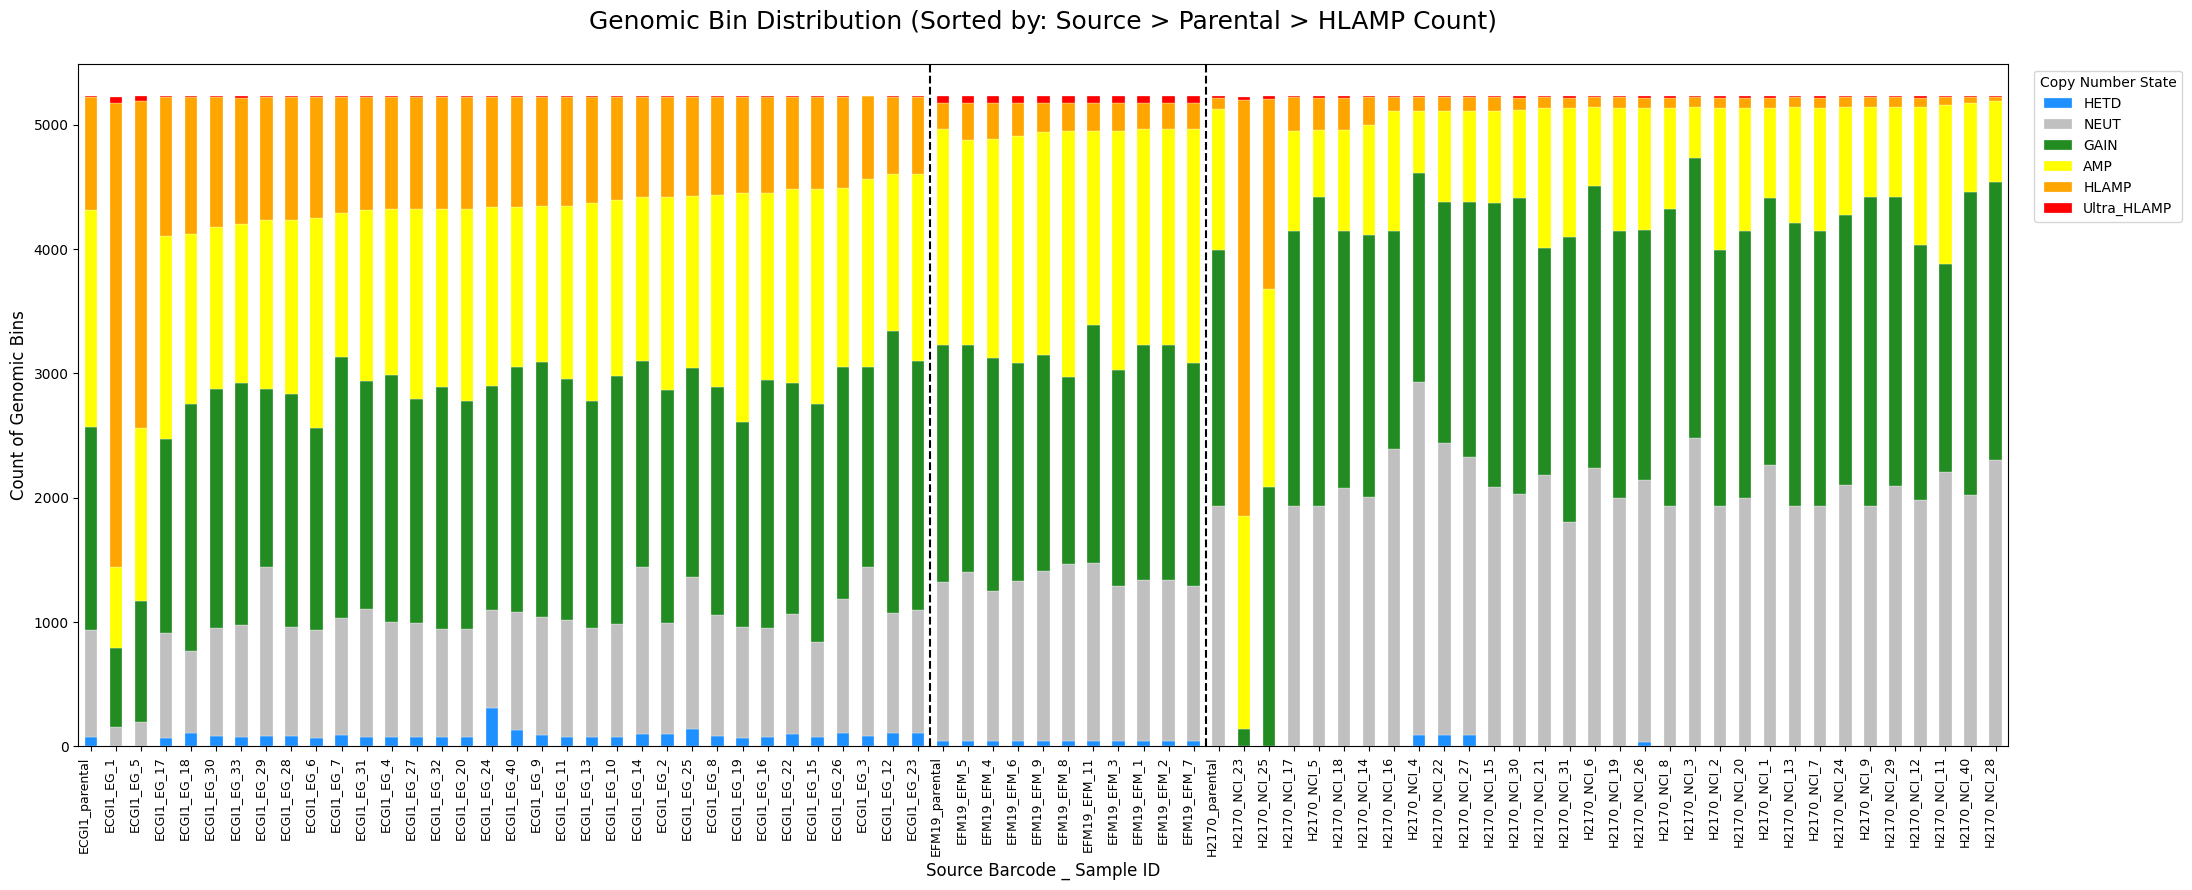

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 전처리: HLAMP2 통합
# cna_seg['Corrected_Call_2'] = cna_seg['Corrected_Call'].replace('HLAMP2', 'HLAMP')

# 2. 샘플별 HLAMP 빈도수 계산
# 각 샘플이 가진 HLAMP(빨간색) 구간의 개수를 미리 구합니다.
hlamp_counts = cna_seg[cna_seg['Reassigned_Event'] == 'HLAMP'].groupby(['source_barcode', 'sample_id']).size().reset_index(name='hlamp_count')

# 3. 전체 샘플 리스트와 HLAMP 카운트 병합 (HLAMP가 0인 샘플도 포함하기 위함)
sample_order_info = cna_seg[['source_barcode', 'sample_id']].drop_duplicates()
sample_order_info = pd.merge(sample_order_info, hlamp_counts, on=['source_barcode', 'sample_id'], how='left').fillna(0)

# 4. 정렬 로직 적용
# - 1순위: source_barcode (가나다/알파벳 순)
# - 2순위: Parental 여부 (Parental이면 0, 아니면 1 -> 0이 먼저 옴)
# - 3순위: HLAMP 카운트 (내림차순 정렬을 위해 마이너스 값을 사용하거나 아래 sort_values 활용)
sample_order_info['is_not_parental'] = sample_order_info['sample_id'].apply(
    lambda x: 0 if 'parental' in str(x).lower() else 1
)

# 정렬 실행: 소스별 -> 파렌탈 먼저 -> HLAMP 많은 순(False)
sample_order_info = sample_order_info.sort_values(
    by=['source_barcode', 'is_not_parental', 'hlamp_count'], 
    ascending=[True, True, False]
)

# 5. 최종 정렬된 라벨 생성
sample_order_info['plot_label'] = sample_order_info['source_barcode'] + "_" + sample_order_info['sample_id']
ordered_labels = sample_order_info['plot_label'].values

# 6. 교차표(Crosstab) 생성 및 순서 재배치
# 원본 데이터에도 plot_label 추가
cna_seg['plot_label'] = cna_seg['source_barcode'] + "_" + cna_seg['sample_id']

dist_table = pd.crosstab(index=cna_seg['plot_label'], 
                         columns=cna_seg['Reassigned_Event'], 
                         dropna=False)

# 위에서 정의한 순서(ordered_labels)대로 행 재배치 및 쌓는 순서(stack_order)대로 열 재배치
stack_order = ['HETD', 'NEUT', 'GAIN', 'AMP', 'HLAMP','Ultra_HLAMP']
existing_order = [col for col in stack_order if col in dist_table.columns]
dist_table = dist_table.reindex(index=ordered_labels, columns=existing_order)

# 7. 색상 매핑
color_map = {
    'HETD': 'dodgerblue', 'NEUT': 'silver', 'GAIN': 'forestgreen', 
    'AMP': 'yellow', 'HLAMP': 'orange', 'Ultra_HLAMP': 'red'
}
current_colors = [color_map[col] for col in existing_order]

# 8. 시각화
plt.figure(figsize=(25, 10))
ax = dist_table.plot(kind='bar', stacked=True, figsize=(22, 9), 
                     color=current_colors, edgecolor='white', linewidth=0.2)

# Source 그룹 구분을 위한 수직선 추가
current_source = ""
for i, label in enumerate(ordered_labels):
    source = label.split('_')[0]
    if current_source != "" and source != current_source:
        plt.axvline(x=i-0.5, color='black', linestyle='--', alpha=1, linewidth=1.5)
    current_source = source

plt.title('Genomic Bin Distribution (Sorted by: Source > Parental > HLAMP Count)', fontsize=18, pad=25)
plt.xlabel('Source Barcode _ Sample ID', fontsize=12)
plt.ylabel('Count of Genomic Bins', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.legend(title='Copy Number State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [203]:
cna_seg['source_barcode'].value_counts()

source_barcode
ECGI1    177786
H2170    167328
EFM19     57519
Name: count, dtype: int64

In [204]:
cna_seg.head(2)

source='EFM19'
cna_seg_sub = cna_seg[cna_seg['source_barcode']==source].copy()

cna_seg_sub.head()

cna_seg_sub.columns

Index(['aliquot_barcode', 'chr', 'start', 'end', 'copy.number', 'event',
       'logR', 'subclone.status', 'Corrected_Copy_Number', 'Corrected_Call',
       'logR_Copy_Number', 'source_barcode', 'sample_id', 'old_source_barcode',
       'old_sample_id', 'Reassigned_Event', 'plot_label'],
      dtype='object')

In [205]:
cna_seg_sub[cna_seg_sub['Corrected_Call']=='HLAMP']['Corrected_Copy_Number'].max()

cna_seg_sub[(cna_seg_sub['Corrected_Call']=='HLAMP2')&(cna_seg_sub['Corrected_Copy_Number']==6)]

cna_seg_sub[cna_seg_sub['Reassigned_Event']=='Unknown']

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label
347858,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_11,EFM19,EFM_11,Unknown,EFM19_EFM_11
353087,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_3,EFM19,EFM_3,Unknown,EFM19_EFM_3
358316,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_6,EFM19,EFM_6,Unknown,EFM19_EFM_6
363545,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_5,EFM19,EFM_5,Unknown,EFM19_EFM_5
368774,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_1,EFM19,EFM_1,Unknown,EFM19_EFM_1
374003,ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_4,EFM19,EFM_4,Unknown,EFM19_EFM_4
379232,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_7,EFM19,EFM_7,Unknown,EFM19_EFM_7
384461,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_9,EFM19,EFM_9,Unknown,EFM19_EFM_9
389690,ECTRES-EFM19-0001-TPX-A02-WGS-KVS1LG,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_2,EFM19,EFM_2,Unknown,EFM19_EFM_2
394919,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,8,113500001,114000000,7,HLAMP3,NaN,0,NaN,NaN,NaN,EFM19,EFM_8,EFM19,EFM_8,Unknown,EFM19_EFM_8


In [206]:
# HOMD Homozygous deletion, ≤ 0 copies
# HETD Heterozygous deletion, 1 copy
# NEUT Neutral change, 2 copies
# GAIN Gain of chromosome, 3 copies
# AMPL Amplification event, 4 copies
# HLAMP High level amplification, < 15 copies
# Ultra-HLAMP High level amplification, ≥ 15 copies

In [207]:
pd.crosstab(index=cna_seg_sub['sample_id'], 
                                 columns=cna_seg_sub['Reassigned_Event'], 
                                 dropna=False)

Reassigned_Event,AMP,GAIN,HETD,HLAMP,NEUT,Ultra_HLAMP,Unknown
sample_id,,,,,,,
EFM_1,1738,1890,41,209,1295,55,1
EFM_11,1564,1913,41,221,1434,55,1
EFM_2,1735,1891,41,209,1296,56,1
EFM_3,1922,1736,41,221,1252,56,1
EFM_4,1759,1877,41,287,1209,55,1
EFM_5,1649,1830,41,294,1359,55,1
EFM_6,1826,1748,41,264,1293,56,1
EFM_7,1877,1798,41,208,1248,56,1
EFM_8,1979,1499,41,223,1430,56,1


In [208]:
# 1. Corrected_Call별로 실제 수치 범위(Min, Max, Median) 한눈에 보기
summary = cna_seg_sub.groupby('Reassigned_Event')['Corrected_Copy_Number'].agg(['min', 'max', 'median', 'count'])
print("--- Event별 통계 요약 ---")
print(summary)

# 2. 특히 'HLAMP'이면서 초고수준 증폭(예: CN > 10)인 구간이 많은 샘플 찾기
extreme_amp = cna_seg_sub[cna_seg_sub['Corrected_Copy_Number'] > 10]
extreme_counts = extreme_amp.groupby('sample_id').size().sort_values(ascending=False)

print("\n--- 초고수준 증폭(CN > 10)이 가장 많은 샘플 Top 5 ---")
print(extreme_counts.head(5))

--- Event별 통계 요약 ---
                   min   max  median  count
Reassigned_Event                           
AMP                4.0   4.0     4.0  19574
GAIN               3.0   3.0     3.0  19825
HETD               1.0   1.0     1.0    451
HLAMP              5.0  14.0     6.0   2579
NEUT               2.0   2.0     2.0  14468
Ultra_HLAMP       15.0  60.0    30.0    611
Unknown            NaN   NaN     NaN      0

--- 초고수준 증폭(CN > 10)이 가장 많은 샘플 Top 5 ---
sample_id
EFM_3     80
EFM_8     79
EFM_6     78
EFM_11    77
EFM_2     77
dtype: int64


In [209]:
import pandas as pd

# 1. 염색체별로 각 Corrected_Call이 몇 번 나타나는지 집계
chr_dist = pd.crosstab(index=cna_seg_sub['chr'], 
                        columns=cna_seg_sub['Reassigned_Event'], 
                        dropna=False)

# 2. 'HLAMP'이 많은 순서대로 정렬해서 출력
print("--- 염색체별 Call 분포 (HLAMP 많은 순) ---")
print(chr_dist.sort_values(by='Ultra_HLAMP', ascending=False))

--- 염색체별 Call 분포 (HLAMP 많은 순) ---
Reassigned_Event   AMP  GAIN  HETD  HLAMP  NEUT  Ultra_HLAMP  Unknown
chr                                                                  
8                  267   459   451    418  1012          407       11
17                  61   132     0    310   804          156        0
20                   4    15     0    239   959           26        0
12                1658     0     0    164   906           22        0
1                 2376   189     0    195  1805            0        0
21                   0     0     0      0   682            0        0
9                 1628     0     0     88   583            0        0
7                 1854     6     0      0  1165            0        0
6                 1166  2334     0      0    64            0        0
5                 1874  1769     0      9     0            0        0
4                  722  3156     0     71     0            0        0
3                 1980  1045     0      0  1155         

In [210]:
# 복제수가 10 이상인 구간만 필터링 (ecDNA 의심 구간)
extreme_segments = cna_seg_sub[cna_seg_sub['Corrected_Copy_Number'] > 10]

# 주요 정보만 선택하여 출력 (상위 20개)
# 컬럼명은 데이터셋에 따라 'start', 'end' 등으로 다를 수 있으니 확인해 주세요.
print("\n--- 초고수준 증폭 구간 상세 위치 (Top 20) ---")
display_cols = ['sample_id', 'chr', 'start', 'end', 'Corrected_Copy_Number']
print(extreme_segments[display_cols].sort_values(by='Corrected_Copy_Number', ascending=False).head(20))


--- 초고수준 증폭 구간 상세 위치 (Top 20) ---
       sample_id chr      start        end  Corrected_Copy_Number
375690     EFM_4  17   37500001   38000000                   60.0
354774     EFM_3  17   37500001   38000000                   57.0
360003     EFM_6  17   37500001   38000000                   57.0
386148     EFM_9  17   37500001   38000000                   57.0
349545    EFM_11  17   37500001   38000000                   56.0
396606     EFM_8  17   37500001   38000000                   56.0
380919     EFM_7  17   37500001   38000000                   55.0
401835  parental  17   37500001   38000000                   55.0
370461     EFM_1  17   37500001   38000000                   55.0
365232     EFM_5  17   37500001   38000000                   54.0
391377     EFM_2  17   37500001   38000000                   54.0
374035     EFM_4   8  129500001  130000000                   48.0
375689     EFM_4  17   37000001   37500000                   46.0
353119     EFM_3   8  129500001  13000000

In [211]:
cna_seg_sub.head(2)

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label
345114,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,1,1000001,1500000,2,NEUT,NaN,0,2.0,NEUT,NaN,EFM19,EFM_11,EFM19,EFM_11,NEUT,EFM19_EFM_11
345115,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,1,1500001,2000000,2,NEUT,-0.3828,0,2.0,NEUT,2.329176,EFM19,EFM_11,EFM19,EFM_11,NEUT,EFM19_EFM_11


In [212]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = cna_seg_sub.copy()
# 1. 데이터 로드 (이미 불러오신 데이터프레임을 df라고 가정)
# bin_id를 생성하여 고유한 유전체 위치 정의
df['bin_id'] = df['chr'].astype(str) + ":" + df['start'].astype(str) + "-" + df['end'].astype(str)

# 2. Pivot Table 만들기
# index: 샘플, columns: 유전체 위치, values: 복제수(또는 logR)
pivot_df = df.pivot(index='aliquot_barcode', columns='bin_id', values='Corrected_Copy_Number')

# 3. 유전체 순서대로 컬럼 정렬 (매우 중요!)
# chr1 -> chr2 ... 순서로 정렬되지 않으면 Heatmap이 엉망이 됩니다.
# 원본 데이터에서 순서를 추출합니다.
bin_order = df[['bin_id', 'chr', 'start']].drop_duplicates().sort_values(['chr', 'start'])['bin_id']
pivot_df = pivot_df[bin_order]

# 4. 분석을 위해 source_barcode 정보 다시 붙이기
# (pivot 과정에서 index가 되었으므로 mapping table 필요)
sample_map = df[['aliquot_barcode', 'source_barcode']].drop_duplicates().set_index('aliquot_barcode')
pivot_df['source_barcode'] = sample_map['source_barcode']

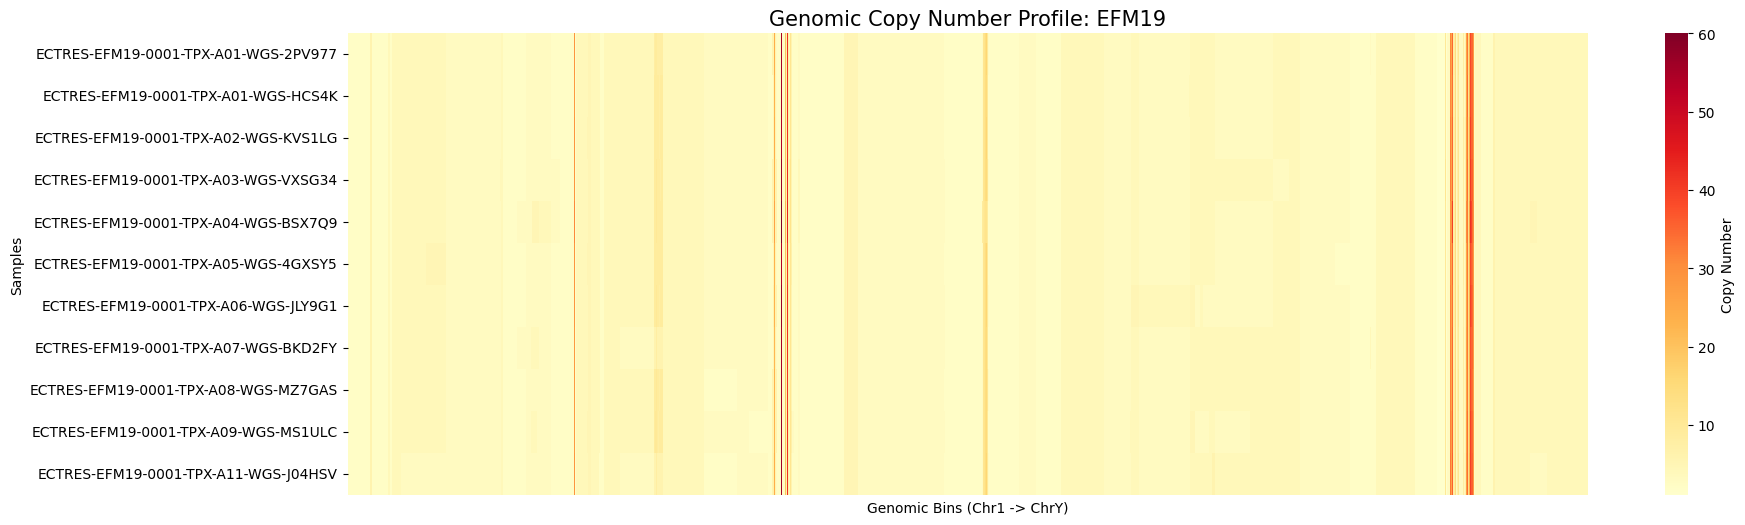

In [213]:
# 색상 지정 (보내주신 이전 차트의 HLAMP/AMP 색상과 맞춤)
# 0: NEUT/HETD, 3: AMP, 4: HLAMP 등 수치에 맞춰 매핑
cmap = {0: '#BDC3C7', 1: '#BDC3C7', 2: '#BDC3C7', 3: '#FFA500', 4: '#FF0000'}

for source in pivot_df['source_barcode'].unique():
    subset = pivot_df[pivot_df['source_barcode'] == source].drop(columns='source_barcode')
    
    # Parental 샘플이 있다면 맨 위로 정렬 (샘플명에 'parental'이 포함된 경우)
    rows = subset.index.tolist()
    parental_rows = [r for r in rows if 'parental' in r.lower()]
    clone_rows = [r for r in rows if 'parental' not in r.lower()]
    subset = subset.reindex(parental_rows + clone_rows)

    plt.figure(figsize=(20, 6))
    # annot=False로 해야 속도가 빠릅니다. 
    sns.heatmap(subset, cmap="YlOrRd", cbar_kws={'label': 'Copy Number'})
    
    plt.title(f"Genomic Copy Number Profile: {source}", fontsize=15)
    plt.xlabel("Genomic Bins (Chr1 -> ChrY)")
    plt.ylabel("Samples")
    plt.xticks([]) # Bin이 너무 많으므로 x축 눈금은 제거
    plt.show()

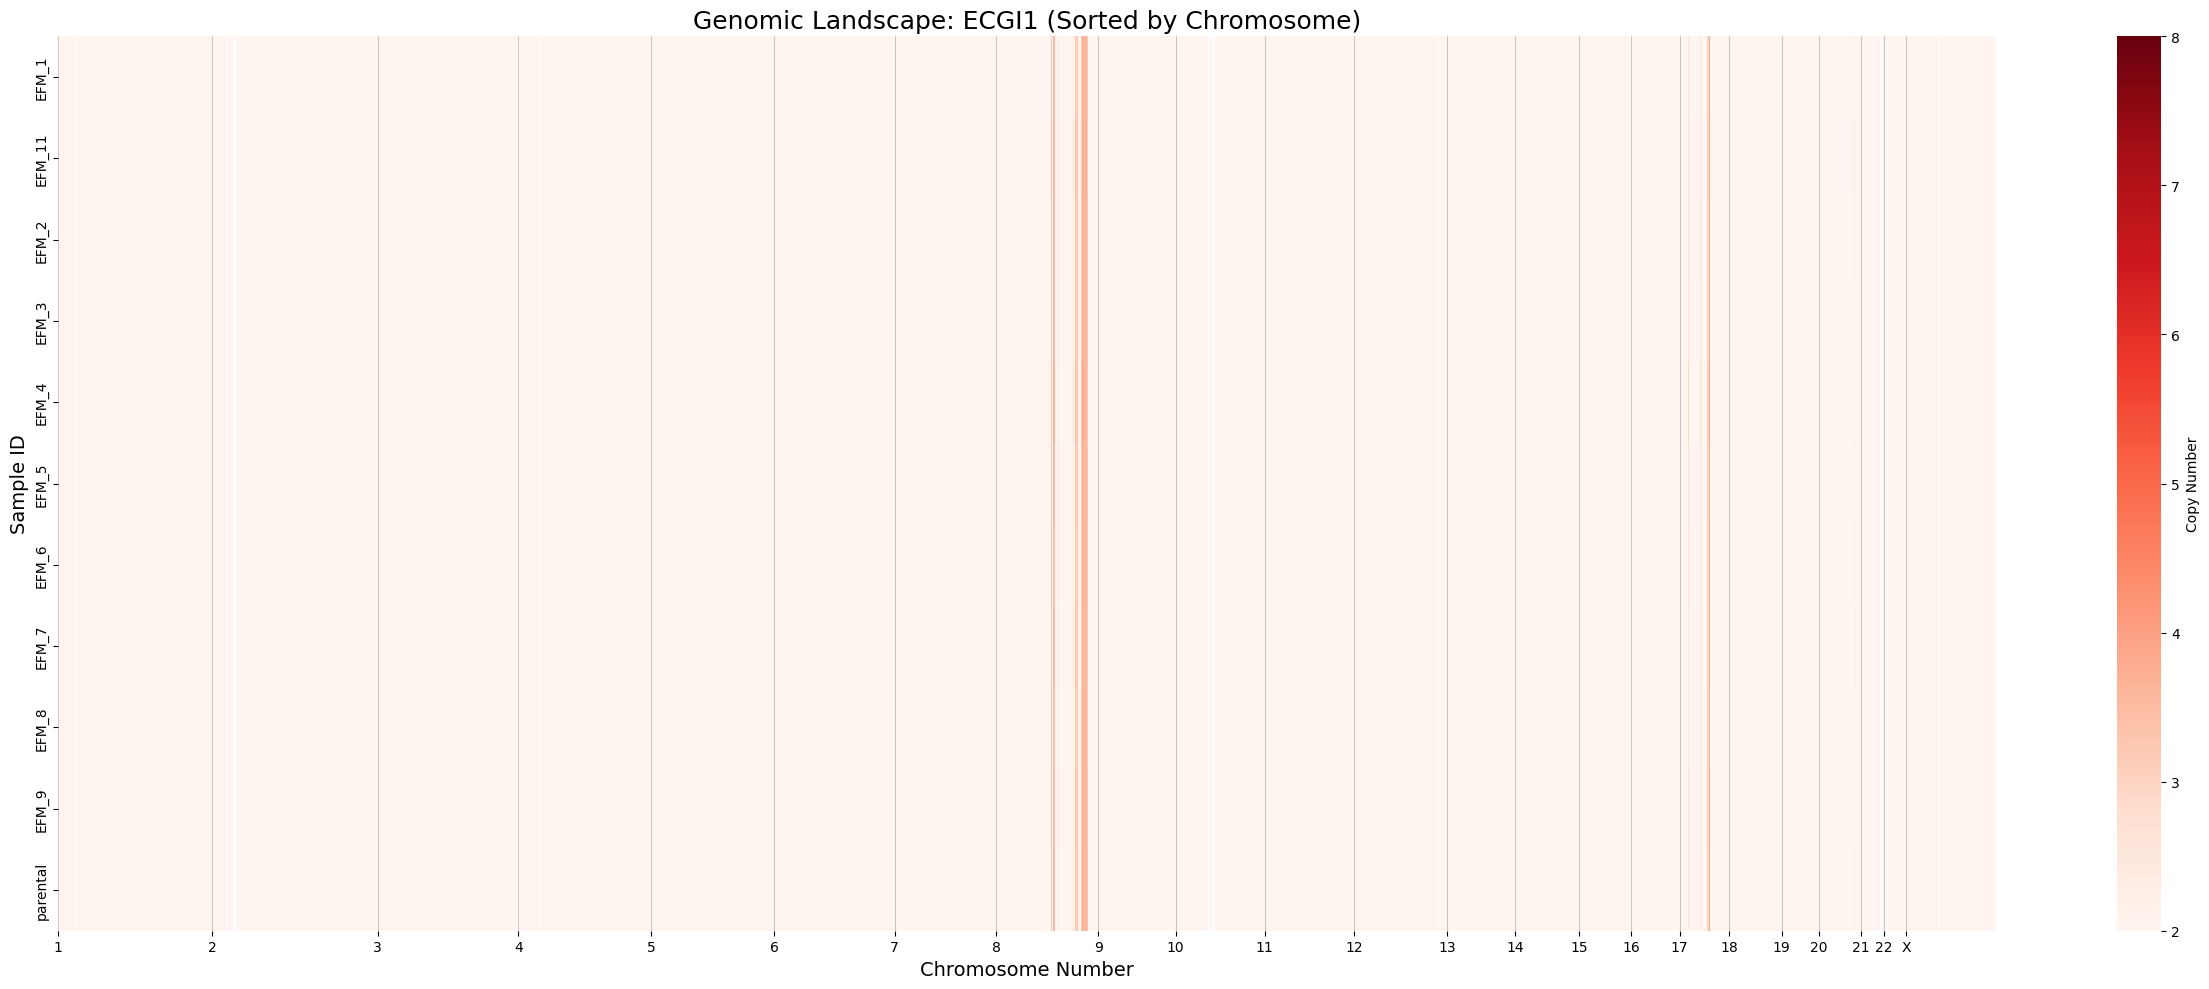

In [214]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 사용자 설정 ---
# target_source = "ECGI1" 
# -----------------

# 1. 특정 계통 필터링
# df_sub = df[df['source_barcode'] == target_source].copy()
df_sub = cna_seg_sub.copy()

# 2. Chromosome 정렬 순서 정의 (1~22, X, Y)
# 숫자로 변환 가능한 건 숫자로, X/Y는 뒤로 보냅니다.
def chr_sort_key(chr_name):
    c = str(chr_name).replace('chr', '').replace('Chr', '')
    if c == 'X': return 23
    if c == 'Y': return 24
    try:
        return int(c)
    except ValueError:
        return 99

df_sub['chr_num'] = df_sub['chr'].apply(chr_sort_key)
df_sub = df_sub.sort_values(['chr_num', 'start'])

# 3. Bin ID 생성 및 Pivot (Y축: sample_id)
# f-string을 써서 정렬된 순서대로 bin_id가 생성되게 합니다.
df_sub['bin_id'] = df_sub['chr'].astype(str) + ":" + df_sub['start'].astype(str)
pivot_df = df_sub.pivot(index='sample_id', columns='bin_id', values='logR')

# 4. Pivot 이후에도 컬럼 순서가 뒤섞이지 않게 재정렬
sorted_bins = df_sub['bin_id'].unique()
pivot_df = pivot_df.reindex(columns=sorted_bins)

# 5. X축 Chromosome 라벨 및 구분선 위치 계산
chr_ticks = []
chr_labels = []
last_chr = None

for i, bin_id in enumerate(sorted_bins):
    current_chr = bin_id.split(':')[0]
    if current_chr != last_chr:
        chr_ticks.append(i)
        chr_labels.append(current_chr.replace('chr', ''))
        last_chr = current_chr
        
        
plt.figure(figsize=(25, 10))

# 0~2(정상/낮음), 3(AMP), 4(HLAMP) 분포에 최적화된 컬러맵
# sns.heatmap(pivot_df, 
#             cmap="YlOrRd", 
#             cbar_kws={'label': 'Copy Number'},
#             yticklabels=True,
#             xticklabels=False) # 개별 Bin 라벨은 숨김
sns.heatmap(pivot_df, 
            cmap="Reds",        # White to Red 기본 컬러맵
            vmin=2,             # 2(정상) 이하를 흰색에 가깝게 처리
            vmax=8,             # 5 이상을 가장 진한 빨강으로 처리
            cbar_kws={'label': 'Copy Number'},
            yticklabels=True,
            xticklabels=False)

# X축에 염색체 번호 표시 (중앙 정렬을 위해 각 구간의 중간 지점으로 계산 가능하나 우선 시작점 표시)
plt.xticks(chr_ticks, chr_labels, fontsize=10)

# 염색체 경계선 (수직선) 추가 - 구분이 훨씬 명확해집니다.
for tick in chr_ticks:
    plt.axvline(x=tick, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

plt.title(f"Genomic Landscape: {target_source} (Sorted by Chromosome)", fontsize=18)
plt.xlabel("Chromosome Number", fontsize=14)
plt.ylabel("Sample ID", fontsize=14)

plt.tight_layout()
plt.show()

In [215]:
aaSuite_gemline_ms=pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260327.csv')
aaSuite_gemline_ms_sub=aaSuite_gemline_ms[aaSuite_gemline_ms['source_barcode']==source]
aaSuite_gemline_ms_sub.shape


(129, 28)

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_aa = aaSuite_gemline_ms_sub.copy()
# ---------------------------------------------------------
# 1. Parental의 ecDNA Interval 추출 및 파싱
# ---------------------------------------------------------
# df_aa는 AmpliconArchitect 결과가 담긴 데이터프레임이라고 가정합니다.
intervals_series = df_aa[(df_aa['sample_id'] == 'parental') & (df_aa['amplicon_type'] == 'ecDNA')]['Intervals']
# intervals_series = df_aa[(df_aa['sample_id'] == 'parental') & (df_aa['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False))]['Intervals']
print(intervals_series)

# 여러 행에 걸쳐 있을 수 있으므로 콤마로 모두 합친 후 리스트로 만듭니다.
all_intervals_str = ",".join(intervals_series.dropna().astype(str))

ecdna_regions = []
for inv in all_intervals_str.split(','):
    inv = inv.strip()
    if not inv: continue
    
    # "8:43225919-43227230" 형태 분리
    chrom, pos = inv.split(':')
    start, end = pos.split('-')
    
    # 'chr' 접두사 통일 (매핑을 위해)
    chrom = chrom.replace('chr', '') 
    ecdna_regions.append((chrom, int(start), int(end)))

# ---------------------------------------------------------
# 2. ichorCNA Segment 데이터 필터링 (Overlap 확인)
# ---------------------------------------------------------
df_sub = cna_seg_sub.copy() # 원본 cna_seg 데이터
df_sub['chr_clean'] = df_sub['chr'].astype(str).str.replace('chr', '')

def check_overlap(row_chr, row_start, row_end, regions):
    for (r_chr, r_start, r_end) in regions:
        if str(row_chr) == str(r_chr):
            # 두 구간이 겹치는지 확인하는 공식: max(start1, start2) <= min(end1, end2)
            if max(row_start, r_start) <= min(row_end, r_end):
                return True
    return False

# Overlap 되는 Bin만 남기기
df_sub['is_ecDNA_target'] = df_sub.apply(lambda row: check_overlap(row['chr_clean'], row['start'], row['end'], ecdna_regions), axis=1)
df_target = df_sub[df_sub['is_ecDNA_target']].copy()

print(f"매핑된 ecDNA 관련 Bin 개수: {len(df_target['start'].unique())}개")
print(df_target.shape)

2417    1:51779188-51790039,1:57048384-57838394,8:7026...
Name: Intervals, dtype: object
매핑된 ecDNA 관련 Bin 개수: 175개
(2277, 19)


In [218]:
# df_target.columns
# df_target['chr'].unique()
# df_target[df_target['sample_id']=='parental']['chr'].unique()

# df_aa[df_aa['sample_id']=='parental'].head(2)

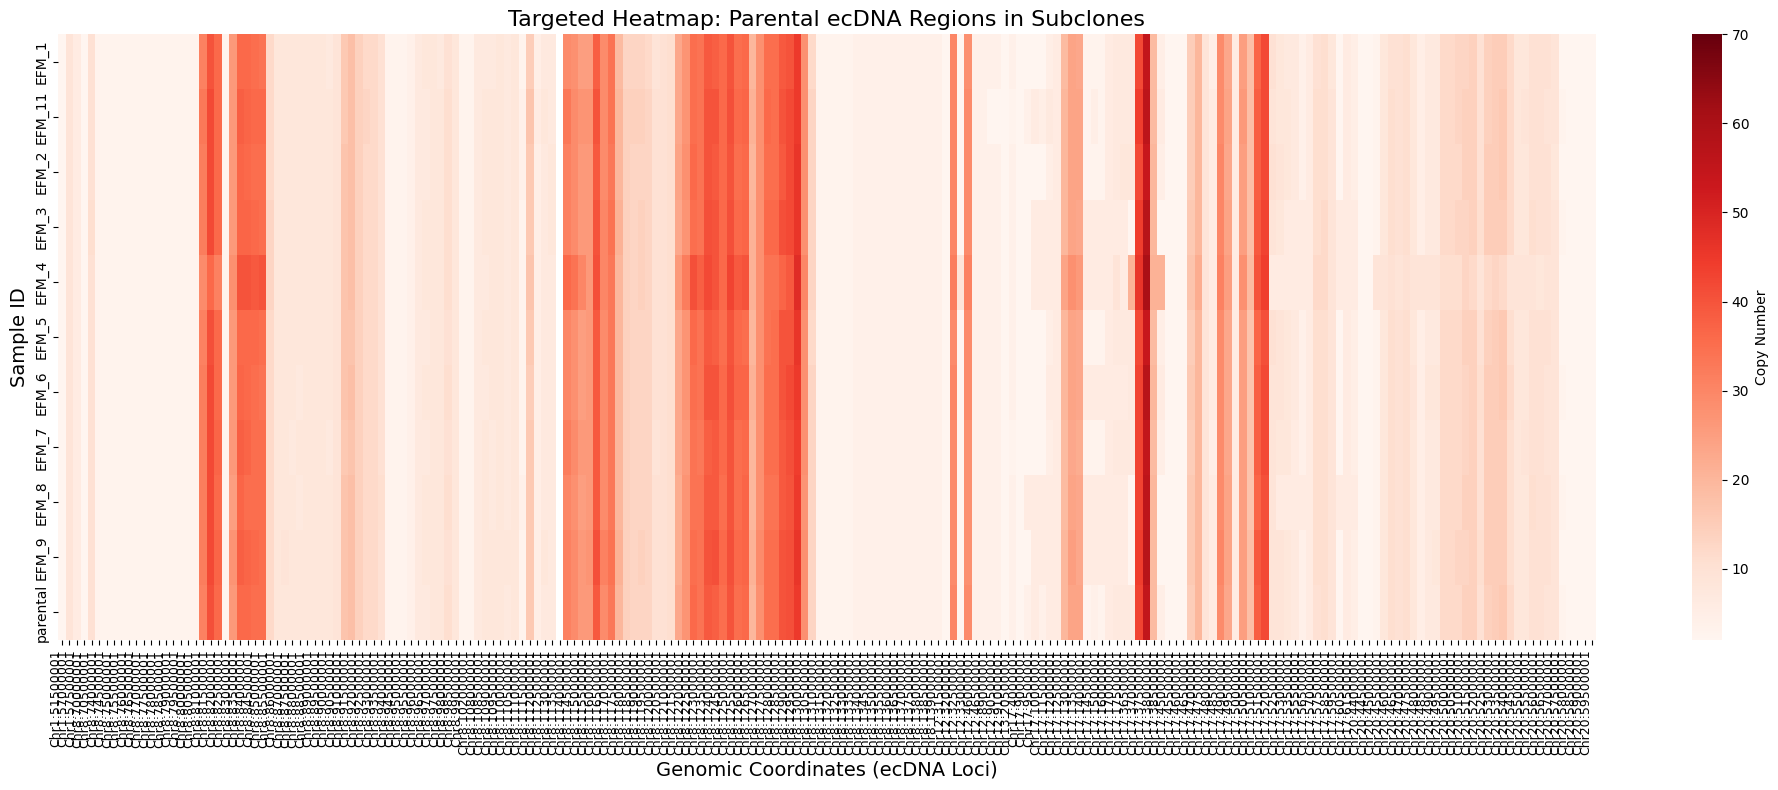

In [220]:
# ---------------------------------------------------------
# 3. 데이터 정렬 및 Pivot (Zoom-in 전용)
# ---------------------------------------------------------
def chr_sort_key(chr_name):
    c = str(chr_name)
    if c == 'X': return 23
    if c == 'Y': return 24
    try: return int(c)
    except ValueError: return 99

df_target['chr_num'] = df_target['chr_clean'].apply(chr_sort_key)
df_target = df_target.sort_values(['chr_num', 'start'])

# Bin ID 생성
df_target['bin_id'] = "Chr" + df_target['chr_clean'] + ":" + df_target['start'].astype(str)
pivot_df = df_target.pivot(index='sample_id', columns='bin_id', values='Corrected_Copy_Number')

# Pivot 후 컬럼 순서 재정렬
sorted_bins = df_target['bin_id'].unique()
pivot_df = pivot_df.reindex(columns=sorted_bins)

# ---------------------------------------------------------
# 4. Zoom-in Heatmap 시각화
# ---------------------------------------------------------
plt.figure(figsize=(20, 8))

# White to Red 컬러맵 적용 (2 이하를 흰색으로 날리고 증폭된 곳만 강조)
sns.heatmap(pivot_df, 
            cmap="Reds", 
            vmin=2,  
            vmax=70, # 최대 Copy Number에 맞게 조절하세요 (HLAMP가 4 이상이라면 6~10 정도가 적당)
            cbar_kws={'label': 'Copy Number'},
            yticklabels=True,
            xticklabels=True) # 확대 뷰이므로 개별 Bin 라벨을 켭니다!

# X축 라벨 회전 (글씨가 겹치지 않게)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=10)

target_source = df_target['source_barcode'].iloc[0] if not df_target.empty else "Unknown"
plt.title(f"Targeted Heatmap: Parental ecDNA Regions in Subclones", fontsize=16)
plt.xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
plt.ylabel("Sample ID", fontsize=14)

# Parental을 위로 올리고 싶다면 (선택사항)
# rows = pivot_df.index.tolist()
# rows.sort(key=lambda x: (0 if 'parental' in x.lower() else 1, x))
# pivot_df = pivot_df.reindex(rows)

plt.tight_layout()
plt.show()

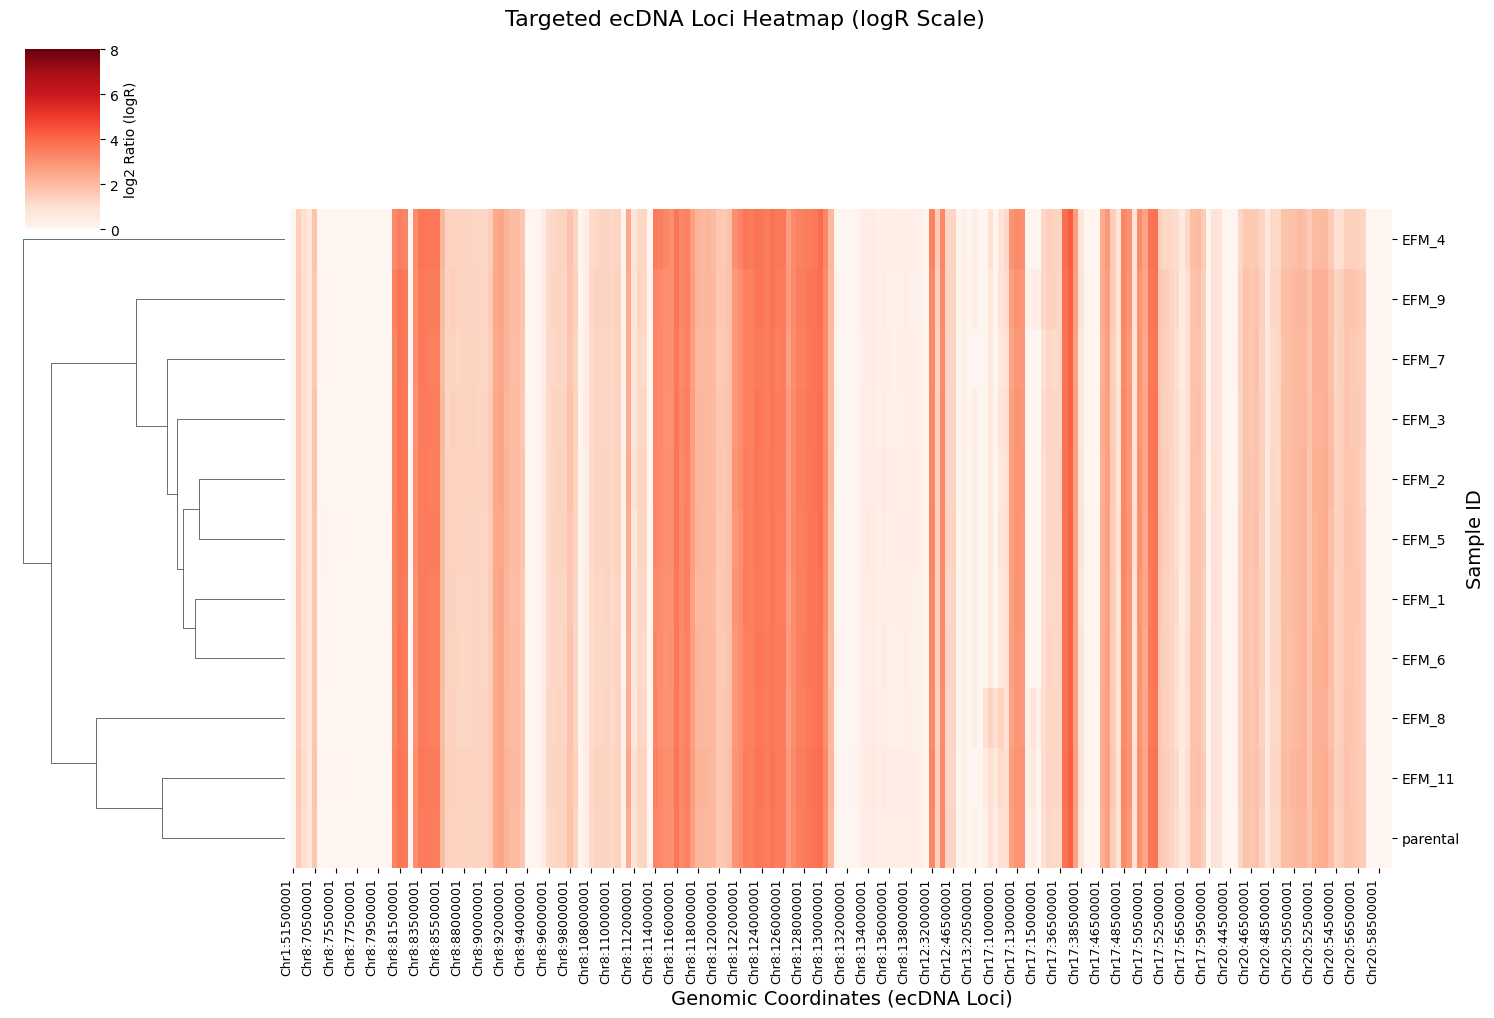

In [221]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. logR 값을 기준으로 Pivot 생성 및 전처리 (에러 방지용)
pivot_df_logR = df_target.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_logR = pivot_df_logR.reindex(columns=sorted_bins)
pivot_df_logR = pivot_df_logR.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# 2. Clustermap 시각화 (Y축 sample_id만 클러스터링!)
# plt.figure(figsize) 대신 clustermap 안에서 figsize를 지정합니다.
cg = sns.clustermap(pivot_df_logR, 
                    row_cluster=True,   # 🟢 Y축(Sample ID) 클러스터링 켜기 (트리 생성)
                    col_cluster=False,  # 🔴 X축(Genomic Bins) 클러스터링 끄기 (순서 그대로)
                    cmap="Reds", 
                    vmin=0, 
                    vmax=8, 
                    figsize=(15, 10),
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 3. 축 라벨 회전 및 폰트 설정 (clustermap은 ax_heatmap 객체에 적용해야 함)
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=90, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

# 4. 타이틀 및 축 이름 설정
cg.fig.suptitle("Targeted ecDNA Loci Heatmap (logR Scale)", fontsize=16, y=1.02)
cg.ax_heatmap.set_xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)

plt.show()

In [222]:
import pandas as pd
from scipy.cluster.hierarchy import fcluster

# 1. Clustermap 객체(cg)에서 덴드로그램 연결 정보(Linkage matrix) 가져오기
Z = cg.dendrogram_row.linkage

# 2. 샘플들을 몇 개의 큰 덩어리(Cluster)로 나눌지 설정 (예: 3개)
# 원하시는 그룹 개수에 맞춰 숫자를 수정하세요.
num_clusters = 5 
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

# 3. 원래 데이터의 인덱스(sample_id)와 클러스터 라벨을 매칭하여 데이터프레임 생성
cluster_table = pd.DataFrame({
    'sample_id': pivot_df_logR.index,
    'Cluster_Group': cluster_labels
})

# 4. Heatmap의 Y축(위에서 아래)에 표시된 순서대로 추출
ordered_indices = cg.dendrogram_row.reordered_ind
ordered_samples = pivot_df_logR.index[ordered_indices]

# 5. 보기 좋게 정렬하여 최종 표 완성
cluster_table['Y_axis_Order'] = cluster_table['sample_id'].apply(lambda x: list(ordered_samples).index(x))
final_cluster_table = cluster_table.sort_values('Y_axis_Order').reset_index(drop=True)

# 표 출력
print(final_cluster_table)

   sample_id  Cluster_Group  Y_axis_Order
0      EFM_4              5             0
1      EFM_9              2             1
2      EFM_7              1             2
3      EFM_3              1             3
4      EFM_2              1             4
5      EFM_5              1             5
6      EFM_1              1             6
7      EFM_6              1             7
8      EFM_8              4             8
9     EFM_11              3             9
10  parental              3            10


In [223]:
# final_cluster_table_erbb2=final_cluster_table.copy()
final_cluster_table_erbb2

,sample_id,Cluster_Group,Y_axis_Order
0,NCI_27,1,0
1,NCI_15,1,1
2,NCI_22,1,2
3,NCI_4,1,3
4,NCI_11,2,4
5,NCI_28,2,5
6,NCI_1,3,6
7,NCI_2,3,7
8,NCI_8,3,8
9,NCI_29,4,9


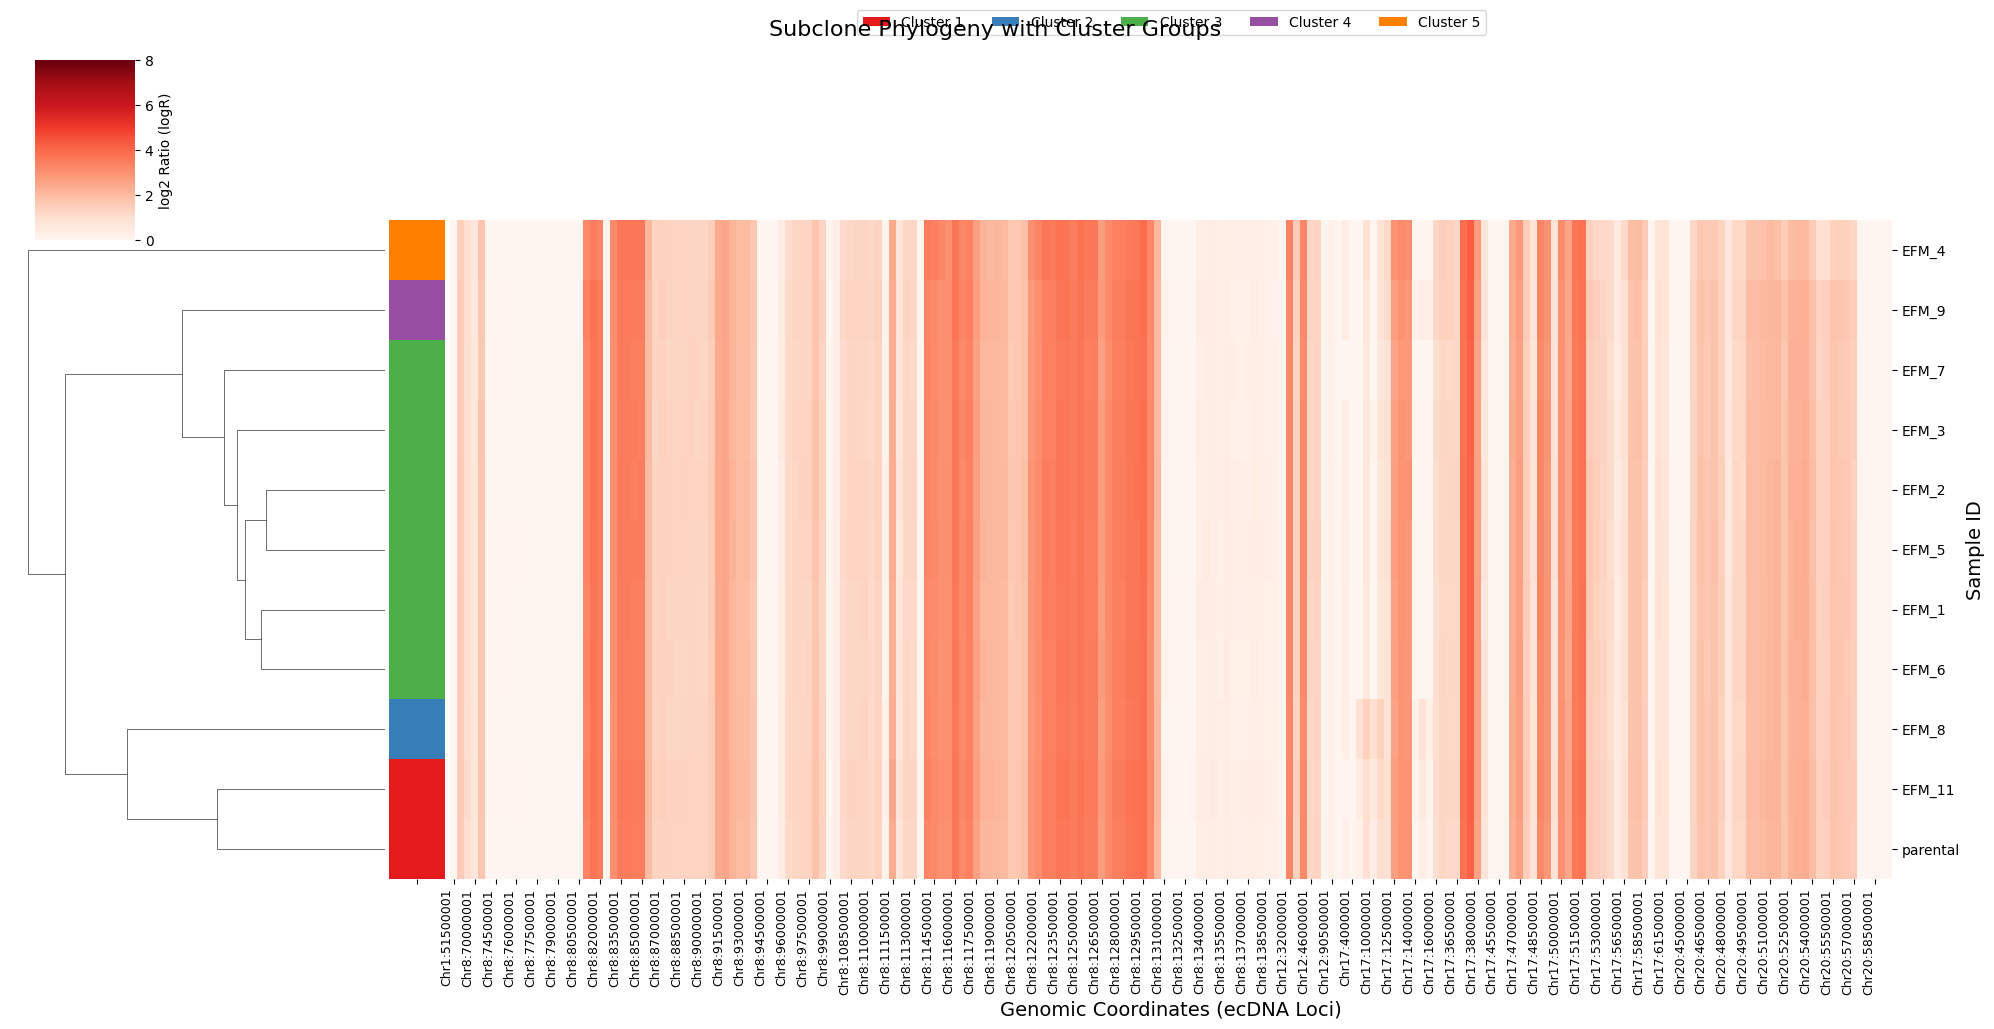

In [224]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

# 1. 데이터 준비 및 전처리 (이전과 동일)
pivot_df_logR = df_target.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_logR = pivot_df_logR.reindex(columns=sorted_bins)
pivot_df_logR = pivot_df_logR.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# ---------------------------------------------------------
# 2. 클러스터링 계산 및 색상 매핑 (💡 새로 추가된 부분)
# ---------------------------------------------------------
# 샘플 간의 거리 계산 및 계통 연결 (Ward 방식 사용)
Z = linkage(pivot_df_logR, method='ward')

# 몇 개의 클러스터로 나눌지 설정 (예: 3개)
num_clusters = 5
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

# 클러스터 그룹별로 할당할 색상 팔레트 생성 (예: Set1, Set2 등)
palette = sns.color_palette("Set1", num_clusters)

# 각 샘플(인덱스)이 어떤 색상을 가져야 하는지 딕셔너리로 매핑
# cluster_labels는 1부터 시작하므로 인덱스 맞추기 위해 -1을 해줍니다.
lut = dict(zip(range(1, num_clusters + 1), palette))
row_colors = pd.Series(cluster_labels, index=pivot_df_logR.index).map(lut)

# ---------------------------------------------------------
# 3. Clustermap 시각화 (row_colors 파라미터 추가!)
# ---------------------------------------------------------
cg = sns.clustermap(pivot_df_logR, 
                    row_cluster=True,   # Y축 덴드로그램 켜기
                    col_cluster=False,  # X축 클러스터링 끄기
                    row_colors=row_colors, # 💡 여기에 생성한 색상 띠를 넣어줍니다!
                    cmap="Reds", 
                    vmin=0, 
                    vmax=8, 
                    figsize=(20, 10),
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 4. 라벨 및 타이틀 세팅
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=90, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

cg.ax_heatmap.set_xlabel("Genomic Coordinates (ecDNA Loci)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)
cg.fig.suptitle("Subclone Phylogeny with Cluster Groups", fontsize=16, y=1.02)

# 5. 범례(Legend) 추가 (어떤 색이 몇 번 그룹인지 표시)
for label, color in lut.items():
    cg.ax_col_dendrogram.bar(0, 0, color=color, label=f'Cluster {label}', linewidth=0)
cg.ax_col_dendrogram.legend(loc="center", ncol=num_clusters, bbox_to_anchor=(0.5, 1.2))

plt.show()

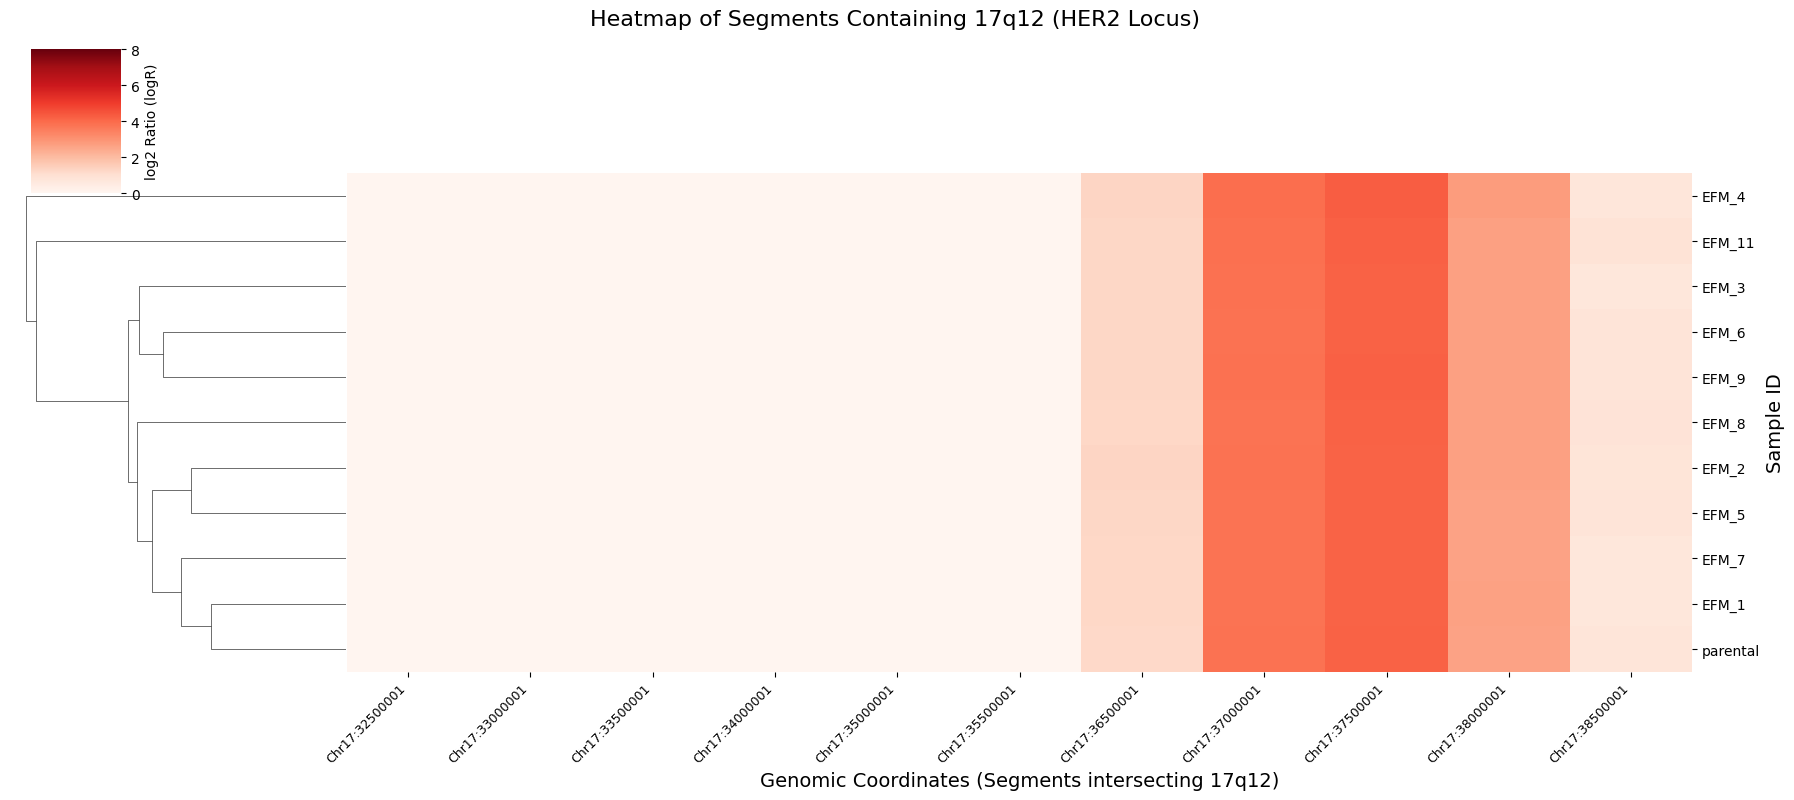

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 17q12 타깃 구역 좌표 설정 ---
target_chr = '17'
# 레퍼런스(hg19/hg38)에 따라 약간 다를 수 있으나, 대략적인 17q12 영역 설정
region_start = 33000000 
region_end = 39000000   

# --- 2. 타깃 구역을 '포함하거나 겹치는' Segment 필터링 ---
df_zoom = cna_seg_sub.copy()
df_zoom['chr_clean'] = df_zoom['chr'].astype(str).str.replace('chr', '')

# 💡 핵심 로직: Segment의 시작점이 타깃의 끝점보다 앞서고, Segment의 끝점이 타깃의 시작점보다 뒤에 있으면 겹침(Overlap)!
overlap_condition = (
    (df_zoom['chr_clean'] == target_chr) & 
    (df_zoom['start'] <= region_end) & 
    (df_zoom['end'] >= region_start)
)
df_17q12_segments = df_zoom[overlap_condition].copy()

# --- 3. Bin ID 생성 및 Pivot ---
# Segment가 한눈에 보이도록 start 좌표를 기준으로 Bin ID 생성
df_17q12_segments['bin_id'] = "Chr" + df_17q12_segments['chr_clean'] + ":" + df_17q12_segments['start'].astype(str)

# X축 순서대로 정렬하기 위해 start 좌표 기준으로 Bin 순서 고정
sorted_bins_17q12 = df_17q12_segments[['bin_id', 'start']].drop_duplicates().sort_values('start')['bin_id']

# Pivot Table 생성 (values는 logR 사용)
pivot_df_17q12 = df_17q12_segments.pivot(index='sample_id', columns='bin_id', values='logR')
pivot_df_17q12 = pivot_df_17q12.reindex(columns=sorted_bins_17q12)

# 클러스터링 에러 방지 (결측치 및 무한대 값 0으로 치환)
pivot_df_17q12 = pivot_df_17q12.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# --- 4. Clustermap 시각화 ---
cg = sns.clustermap(pivot_df_17q12, 
                    row_cluster=True,   # Y축(샘플) 클러스터링 켜기
                    col_cluster=False,  # X축(염기서열) 순서 유지
                    cmap="Reds", 
                    vmin=0, 
                    vmax=8, 
                    figsize=(18, 8),    # X축이 길어질 수 있으므로 가로 비율 확보
                    cbar_kws={'label': 'log2 Ratio (logR)'})

# 축 라벨 및 폰트 세팅
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xmajorticklabels(), rotation=45, ha='right', fontsize=9)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_ymajorticklabels(), fontsize=10)

cg.ax_heatmap.set_xlabel("Genomic Coordinates (Segments intersecting 17q12)", fontsize=14)
cg.ax_heatmap.set_ylabel("Sample ID", fontsize=14)
cg.fig.suptitle("Heatmap of Segments Containing 17q12 (HER2 Locus)", fontsize=16, y=1.03)

plt.show()

In [145]:
cna_seg_sub.head()

,aliquot_barcode,chr,start,end,copy.number,event,logR,subclone.status,Corrected_Copy_Number,Corrected_Call,logR_Copy_Number,source_barcode,sample_id,old_source_barcode,old_sample_id,Reassigned_Event,plot_label
5229,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,1000001,1500000,2,NEUT,NaN,0,2.0,NEUT,NaN,H2170,NCI_40,ECGI1,EG_21,NEUT,H2170_NCI_40
5230,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,1500001,2000000,2,NEUT,-0.2624,0,2.0,NEUT,2.320628,H2170,NCI_40,ECGI1,EG_21,NEUT,H2170_NCI_40
5231,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,2000001,2500000,2,NEUT,NaN,0,2.0,NEUT,NaN,H2170,NCI_40,ECGI1,EG_21,NEUT,H2170_NCI_40
5232,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,3000001,3500000,2,NEUT,-0.4724,0,2.0,NEUT,2.006269,H2170,NCI_40,ECGI1,EG_21,NEUT,H2170_NCI_40
5233,ECTRES-ECGI1-0001-TPX-A21-WGS-1UM757,1,4000001,4500000,2,NEUT,-0.6311,0,2.0,NEUT,1.797280,H2170,NCI_40,ECGI1,EG_21,NEUT,H2170_NCI_40


In [226]:
final_cluster_table.to_csv(f'../summary/ichorCNA/ichorCNA_cna_seg_cluster_{source}_20260331.csv', index=False)
# ichor_df.to_csv('../summary/ichorCNA_summary_params_20260331.csv', index=False)
